# 🏎️ Projet F1 — Partie ML : Machine Learning & Optimisation
## Meilleur Pilote de l'Histoire : Score Composite via ACP

> **Repo :** [spidersweep/f1-pyspark-analysis](https://github.com/spidersweep/f1-pyspark-analysis)  
> **Dépendance :** Ce notebook lit les données produites par `partie1_ingestion_preparation.ipynb`  
> **Entrée :** `../data/processed/` — CSV nettoyés exportés par la Partie 1  
> **Sortie :** `../data/processed/` — visualisations dans `../data/`

**Objectif :** Calculer un indicateur objectif permettant de déterminer le meilleur pilote de l'histoire de la Formule 1, en neutralisant l'avantage technologique des voitures selon les époques.

**Pipeline :**
1. Chargement des données nettoyées issues de la Partie 1 (Parquet/CSV processed)
2. Feature Engineering — métriques brutes par pilote/saison
3. Neutralisation de l'avantage voiture (standardisation intra-saison par rapport au meilleur constructeur)
4. Correction de l'ère technologique (z-score inter-époques)
5. **ACP** (Analyse en Composantes Principales) via **scikit-learn**
6. Score composite pondéré → Classement final

**Dépendances supplémentaires :** `scikit-learn` (non présent dans `requirements.txt` — voir note en fin de notebook).


## 1. Imports & Configuration

In [99]:
# ── Dépendance système (Windows uniquement — identique à partie1) ────────
import os
import sys

if sys.platform == 'win32':
    os.environ["HADOOP_HOME"] = "C:\\hadoop"
    os.environ["PATH"] = "C:\\hadoop\\bin;" + os.environ["PATH"]

# ── Librairies standard ────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Machine Learning (scikit-learn) ───────────────────────────────────────
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer

# ── PySpark ───────────────────────────────────────────────────────────────
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import IntegerType
from pyspark.sql.window import Window

# ── Style matplotlib — thème F1 ──────────────────────────────────────────
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['axes.facecolor'] = '#1a1a2e'
plt.rcParams['figure.facecolor'] = '#16213e'
plt.rcParams['text.color'] = 'white'
plt.rcParams['axes.labelcolor'] = 'white'
plt.rcParams['xtick.color'] = 'white'
plt.rcParams['ytick.color'] = 'white'
plt.rcParams['axes.edgecolor'] = '#e50000'
plt.rcParams['grid.color'] = '#333355'
plt.rcParams['grid.alpha'] = 0.4
PALETTE_F1 = ['#e50000', '#ffffff', '#ff8c00', '#00d2ff', '#ffd700', '#c0c0c0',
              '#39ff14', '#ff69b4', '#4169e1', '#00ced1']

# ── Utilitaire ────────────────────────────────────────────────────────────
def weighted_mean(group, col, weight='races'):
    """Moyenne pondérée par le nombre de courses, en ignorant les NaN."""
    valid = group[[col, weight]].dropna()
    if valid.empty or valid[weight].sum() == 0:
        return np.nan
    return np.average(valid[col], weights=valid[weight])

print("✅ Imports OK")

✅ Imports OK


## 2. Session Spark & Chargement des Données

In [100]:
spark = (
    SparkSession.builder
    .appName("F1_Projet_Groupe")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")
print("✅ Session Spark initialisée")
print(f"   Version Spark : {spark.version}")

✅ Session Spark initialisée
   Version Spark : 3.5.4


In [101]:
PROCESSED_PATH = "C:/Users/Dell/Documents/ibou/USPN_BIDABI1/semestre 2/intro_pyspark/projet/data/processed/"

def load_clean(filename):
    """Charge un CSV nettoyé depuis data/processed/ (sortie de partie1)."""
    path = PROCESSED_PATH + filename
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"Fichier introuvable : {path}\n"
            f"→ Exécuter d'abord partie1_ingestion_preparation.ipynb"
        )
    return spark.read.option("header", True).option("inferSchema", True).csv(path)

results_sdf               = load_clean("results_clean.csv")
races_sdf                 = load_clean("races_clean.csv")
drivers_sdf               = load_clean("drivers_clean.csv")
constructors_sdf          = load_clean("constructors_clean.csv")
driver_standings_sdf      = load_clean("driver_standings_clean.csv")
constructor_standings_sdf = load_clean("constructor_standings_clean.csv")
qualifying_sdf            = load_clean("qualifying_clean.csv")



## 3. Feature Engineering (PySpark)

On construit pour chaque couple **(pilote, saison)** les métriques brutes suivantes :

| Feature | Description |
|---|---|
| `wins` | Nombre de victoires |
| `podiums` | Nombre de podiums (top 3) |
| `points` | Points totaux sur la saison |
| `races` | Courses disputées |
| `dnf_rate` | Taux d'abandon (non-terminé) |
| `avg_finish_pos` | Position d'arrivée moyenne |
| `avg_grid_pos` | Position de départ moyenne |
| `positions_gained` | Places gagnées en moyenne (départ → arrivée) |
| `pole_positions` | Nombre de poles en qualif |
| `avg_quali_gap_pct` | Écart moyen en % au meilleur temps en qualif |
| `consistency` | 1 - écart-type normalisé des positions |

In [102]:
# ── Jointure principale results + races ──────────────────────────────────
results_races = results_sdf.join(
    races_sdf.select("raceId", "year", "name"),
    on="raceId", how="left"
)
results_races = results_races.filter(F.col("year") >= 1950)

# ── Agrégation par (driverId, year) ──────────────────────────────────────
driver_season = results_races.groupBy("driverId", "year").agg(
    F.count("raceId").alias("races"),
    F.sum(F.when(F.col("positionOrder") == 1, 1).otherwise(0)).alias("wins"),
    F.sum(F.when(F.col("positionOrder") <= 3, 1).otherwise(0)).alias("podiums"),
    F.sum("points").alias("points"),
    F.avg("positionOrder").alias("avg_finish_pos"),
    F.avg("grid").alias("avg_grid_pos"),
    F.avg(F.col("grid") - F.col("positionOrder")).alias("positions_gained"),
    F.sum(F.when(F.col("finished") == False, 1).otherwise(0)).alias("dnf"),
)

driver_season = (
    driver_season
    .withColumn("dnf_rate",    F.col("dnf") / F.col("races"))
    .withColumn("win_rate",    F.col("wins") / F.col("races"))
    .withColumn("podium_rate", F.col("podiums") / F.col("races"))
    .drop("dnf")
)

print("driver_season schema :")
driver_season.printSchema()
driver_season.show(5)

driver_season schema :
root
 |-- driverId: integer (nullable = true)
 |-- year: integer (nullable = true)
 |-- races: long (nullable = false)
 |-- wins: long (nullable = true)
 |-- podiums: long (nullable = true)
 |-- points: double (nullable = true)
 |-- avg_finish_pos: double (nullable = true)
 |-- avg_grid_pos: double (nullable = true)
 |-- positions_gained: double (nullable = true)
 |-- dnf_rate: double (nullable = true)
 |-- win_rate: double (nullable = true)
 |-- podium_rate: double (nullable = true)

+--------+----+-----+----+-------+------+------------------+------------------+-------------------+-------------------+--------+-------------------+
|driverId|year|races|wins|podiums|points|    avg_finish_pos|      avg_grid_pos|   positions_gained|           dnf_rate|win_rate|        podium_rate|
+--------+----+-----+----+-------+------+------------------+------------------+-------------------+-------------------+--------+-------------------+
|      10|2008|   18|   0|      1|  25.0

In [103]:
# ── Qualifying : poles & écart moyen au meilleur temps ──────────────────
def parse_time(col_name):
    """Convertit 'mm:ss.mmm' → millisecondes (Long)."""
    return (
        F.when(F.col(col_name).isNull() | (F.col(col_name) == r'\N'), None)
         .otherwise(
            (F.split(F.col(col_name), ":")[0].cast("long") * 60000) +
            (F.split(F.split(F.col(col_name), ":")[1], "\\.")[0].cast("long") * 1000) +
            F.split(F.split(F.col(col_name), ":")[1], "\\.")[1].cast("long")
         )
    )

quali_sdf2 = (
    qualifying_sdf
    .join(races_sdf.select("raceId", "year"), on="raceId")
    .withColumn("q3_ms", parse_time("q3"))
    .withColumn("q2_ms", parse_time("q2"))
    .withColumn("q1_ms", parse_time("q1"))
    .withColumn("best_lap_ms", F.coalesce(F.col("q3_ms"), F.col("q2_ms"), F.col("q1_ms")))
)

race_best_ms = quali_sdf2.groupBy("raceId").agg(F.min("best_lap_ms").alias("race_best_ms"))

quali_enriched = (
    quali_sdf2.join(race_best_ms, on="raceId")
    .withColumn("gap_pct",
        F.when(
            F.col("race_best_ms").isNotNull() & F.col("best_lap_ms").isNotNull(),
            (F.col("best_lap_ms") - F.col("race_best_ms")) / F.col("race_best_ms") * 100
        ).otherwise(None))
)

quali_agg = quali_enriched.groupBy("driverId", "year").agg(
    F.sum(F.when(F.col("pole_position") == True, 1).otherwise(0)).alias("pole_positions"),
    F.avg("gap_pct").alias("avg_quali_gap_pct")
)

# ── Consistance ───────────────────────────────────────────────────────────
consistency_df = (
    results_races.groupBy("driverId", "year")
    .agg(
        F.stddev("positionOrder").alias("std_finish"),
        F.avg("positionOrder").alias("mean_finish")
    )
    .withColumn("cv", F.col("std_finish") / (F.col("mean_finish") + 1e-9))
    .withColumn("consistency", F.lit(1.0) / (F.col("cv") + 1.0))
)

# ── Jointure finale features brutes ──────────────────────────────────────
features_sdf = (
    driver_season
    .join(quali_agg, on=["driverId", "year"], how="left")
    .join(consistency_df.select("driverId", "year", "consistency"),
          on=["driverId", "year"], how="left")
    .filter(F.col("races") >= 5)
)

print(f"✅ Features calculées : {features_sdf.count()} lignes (pilote×saison)")
features_sdf.show(5)

✅ Features calculées : 1763 lignes (pilote×saison)
+--------+----+-----+----+-------+------+------------------+------------------+-------------------+-------------------+--------+-------------------+--------------+------------------+------------------+
|driverId|year|races|wins|podiums|points|    avg_finish_pos|      avg_grid_pos|   positions_gained|           dnf_rate|win_rate|        podium_rate|pole_positions| avg_quali_gap_pct|       consistency|
+--------+----+-----+----+-------+------+------------------+------------------+-------------------+-------------------+--------+-------------------+--------------+------------------+------------------+
|      10|2008|   18|   0|      1|  25.0|10.444444444444445|11.055555555555555| 0.6111111111111112| 0.2222222222222222|     0.0|0.05555555555555555|             0|1.3855174091989684|0.6603873542525872|
|      19|2007|   17|   0|      0|   0.0|15.647058823529411|16.058823529411764| 0.4117647058823529|0.29411764705882354|     0.0|             

## 4. Score Brut — Avant Neutralisation

> On calcule ici un **premier score de référence** à partir des métriques brutes,  
> **sans aucune correction voiture ni correction d'ère**.  
> Ce score servira de baseline de comparaison avec le score ajusté (Section 7).

**Variables utilisées :**  
`win_rate`, `podium_rate`, `avg_finish_pos`, `positions_gained`, `dnf_rate`,  
`pole_positions`, `avg_quali_gap_pct`, `consistency`

In [104]:
# ── 4a. Conversion Spark → Pandas & agrégation carrière (brute) ──────────
features_pdf_brut = features_sdf.toPandas()
drivers_pdf       = drivers_sdf.toPandas()

def get_era(year):
    if year < 1960: return "1950s"
    elif year < 1970: return "1960s"
    elif year < 1980: return "1970s"
    elif year < 1990: return "1980s"
    elif year < 2000: return "1990s"
    elif year < 2010: return "2000s"
    elif year < 2020: return "2010s"
    else: return "2020s"

FEATURE_COLS_RAW = [
    'win_rate', 'podium_rate',
    'avg_finish_pos', 'avg_grid_pos', 'positions_gained',
    'dnf_rate', 'pole_positions', 'avg_quali_gap_pct', 'consistency'
]

career_records_brut = []
for driver_id, grp in features_pdf_brut.groupby('driverId'):
    record = {
        'driverId'      : driver_id,
        'total_races'   : grp['races'].sum(),
        'total_wins'    : grp['wins'].sum(),
        'total_podiums' : grp['podiums'].sum(),
        'total_seasons' : grp['year'].nunique(),
        'career_span'   : grp['year'].max() - grp['year'].min() + 1,
        'first_year'    : grp['year'].min(),
        'last_year'     : grp['year'].max(),
        'era'           : get_era(grp.sort_values('races', ascending=False)['year'].iloc[0]),
    }
    for col in FEATURE_COLS_RAW:
        if col in grp.columns:
            record[f'career_{col}'] = weighted_mean(grp, col, 'races')
    career_records_brut.append(record)

career_df_brut = (
    pd.DataFrame(career_records_brut)
    .merge(drivers_pdf[['driverId', 'forename', 'surname', 'nationality', 'fullName']],
           on='driverId', how='left')
)
career_df_brut['driver_name'] = career_df_brut['fullName']

career_df_brut_filtered = (
    career_df_brut[career_df_brut['total_races'] >= 50]
    .copy()
    .reset_index(drop=True)
)
print(f"✅ {len(career_df_brut_filtered)} pilotes avec ≥ 50 courses (score brut)")
career_df_brut_filtered[['driver_name', 'total_races', 'total_wins', 'total_seasons']] \
    .sort_values('total_wins', ascending=False).head(10)

✅ 152 pilotes avec ≥ 50 courses (score brut)


,driver_name,total_races,total_wins,total_seasons
0,Lewis Hamilton,356,105,18
21,Michael Schumacher,308,91,19
139,Max Verstappen,209,63,10
15,Sebastian Vettel,300,53,16
55,Alain Prost,202,51,13
50,Ayrton Senna,159,41,10
3,Fernando Alonso,404,32,21
47,Nigel Mansell,183,30,12
112,Jackie Stewart,100,27,9
84,Niki Lauda,173,25,12


In [105]:
# ── 4b. ACP sur features brutes ──────────────────────────────────────────
PCA_FEATURES_BRUT = [f for f in [
    'career_win_rate',
    'career_podium_rate',
    'career_avg_finish_pos',
    'career_positions_gained',
    'career_dnf_rate',
    'career_pole_positions',
    'career_avg_quali_gap_pct',
    'career_consistency',
] if f in career_df_brut_filtered.columns]

X_brut = career_df_brut_filtered[PCA_FEATURES_BRUT].copy()
imputer_brut = SimpleImputer(strategy='median')
X_brut_imputed = imputer_brut.fit_transform(X_brut)
scaler_brut = StandardScaler()
X_brut_scaled = scaler_brut.fit_transform(X_brut_imputed)

# Correction polarité négative
NEGATIVE_POLARITY_BRUT = {
    'career_avg_finish_pos'    : True,
    'career_dnf_rate'          : True,
    'career_avg_quali_gap_pct' : True,
}
X_brut_corrected = X_brut_scaled.copy()
for i, feat in enumerate(PCA_FEATURES_BRUT):
    if NEGATIVE_POLARITY_BRUT.get(feat, False):
        X_brut_corrected[:, i] *= -1

# Nombre de composantes pour 80% variance
pca_brut_full = PCA(n_components=None, random_state=42)
pca_brut_full.fit(X_brut_corrected)
cumvar_brut = np.cumsum(pca_brut_full.explained_variance_ratio_)
n_comp_80_brut = int(np.argmax(cumvar_brut >= 0.80)) + 1
print(f"✅ Composantes nécessaires pour 80% variance (brut) : {n_comp_80_brut}")
print(f"   Variance cumulée (PC1..PC{n_comp_80_brut}) : {cumvar_brut[n_comp_80_brut-1]:.2%}")

# ACP finale brute
pca_brut = PCA(n_components=n_comp_80_brut, random_state=42)
X_pca_brut = pca_brut.fit_transform(X_brut_corrected)
weights_brut = pca_brut.explained_variance_ratio_
score_brut_raw = X_pca_brut @ weights_brut

# Normalisation 0-100
s_min, s_max = score_brut_raw.min(), score_brut_raw.max()
career_df_brut_filtered['score_brut'] = (score_brut_raw - s_min) / (s_max - s_min) * 100

ranking_brut = (
    career_df_brut_filtered
    .sort_values('score_brut', ascending=False)
    .reset_index(drop=True)
)
ranking_brut.index = ranking_brut.index + 1  # 1-based

print("\n🏆 TOP 20 SCORE BRUT (sans neutralisation voiture/ère) :")
print("="*70)
cols_disp = ['driver_name', 'nationality', 'total_wins', 'total_podiums', 'total_races', 'score_brut']
print(ranking_brut[cols_disp].head(20).to_string())

✅ Composantes nécessaires pour 80% variance (brut) : 3
   Variance cumulée (PC1..PC3) : 82.27%

🏆 TOP 20 SCORE BRUT (sans neutralisation voiture/ère) :
           driver_name    nationality  total_wins  total_podiums  total_races  score_brut
1       Lewis Hamilton        British         105            202          356  100.000000
2       Max Verstappen          Dutch          63            112          209   92.942114
3     Sebastian Vettel         German          53            122          300   81.595533
4   Michael Schumacher         German          91            155          308   80.744167
5          Juan Fangio      Argentine          24             35           56   79.833863
6      Charles Leclerc     Monegasque           8             43          149   72.968908
7         Nico Rosberg         German          23             57          206   71.129465
8          Alain Prost         French          51            106          202   68.646422
9            Jim Clark        British 

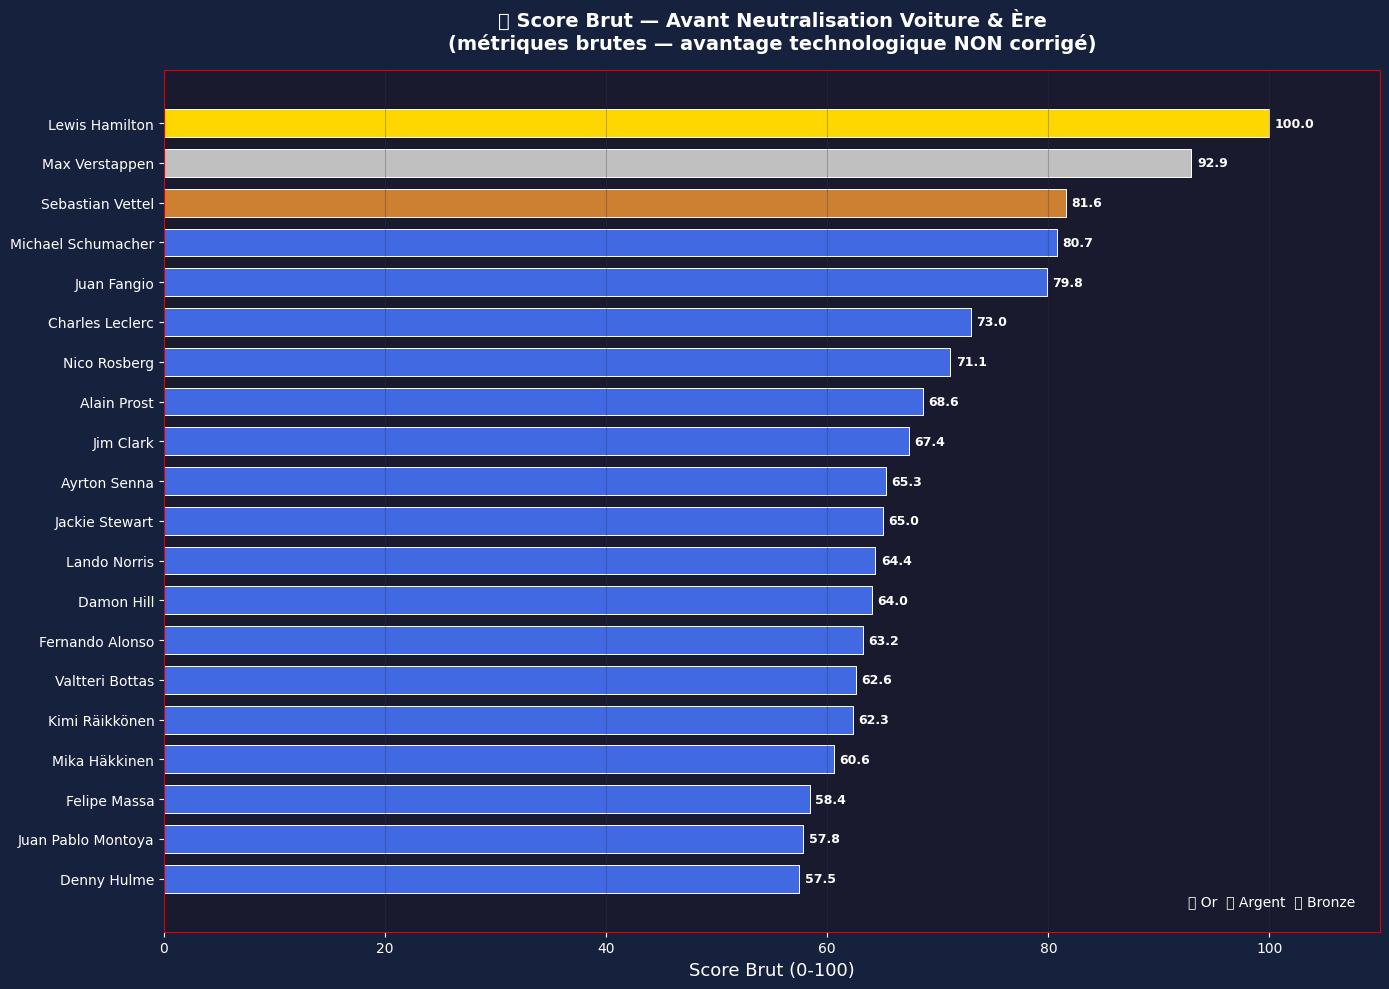

✅ Score brut calculé et visualisé


In [106]:
# ── 4c. Visualisation Score Brut — Top 20 ───────────────────────────────
top20_brut = ranking_brut.head(20).iloc[::-1]

fig, ax = plt.subplots(figsize=(14, 10))
colors = [
    '#ffd700' if i == len(top20_brut)-1 else
    '#c0c0c0' if i == len(top20_brut)-2 else
    '#cd7f32' if i == len(top20_brut)-3 else
    '#4169e1'
    for i in range(len(top20_brut))
]
bars = ax.barh(top20_brut['driver_name'], top20_brut['score_brut'],
               color=colors, edgecolor='white', linewidth=0.7, height=0.7)
for bar, score in zip(bars, top20_brut['score_brut']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{score:.1f}', va='center', ha='left', fontsize=9,
            color='white', fontweight='bold')
ax.set_xlim(0, 110)
ax.set_xlabel('Score Brut (0-100)', fontsize=13)
ax.set_title('📊 Score Brut — Avant Neutralisation Voiture & Ère\n'
             '(métriques brutes — avantage technologique NON corrigé)',
             fontsize=14, fontweight='bold', pad=15)
ax.grid(axis='x', alpha=0.3)
ax.text(0.98, 0.03, '🥇 Or  🥈 Argent  🥉 Bronze',
        transform=ax.transAxes, ha='right', fontsize=10, color='white')
plt.tight_layout()
plt.savefig("score_brut_top20.png", dpi=150, bbox_inches='tight',
            facecolor='#16213e')
plt.show()
print("✅ Score brut calculé et visualisé")

## 5. Neutralisation de l'Avantage Voiture

**Problème :** Un pilote dominant dans une voiture supérieure (ex. Schumacher avec Ferrari 2002-2004, Hamilton avec Mercedes 2014-2020) obtient mécaniquement de meilleures métriques brutes.

**Solution en deux étapes :**

### 5a. Relativisation intra-saison par rapport au meilleur constructeur
Pour chaque saison, on rapporte les performances du pilote **à la moyenne du top-constructeur** de cette saison. Cela neutralise partiellement l'avantage technologique.

### 5b. Correction de l'ère technologique (décennies)
On standardise ensuite par ère (blocs de 10 ans) pour que les pilotes des années 1950 soient comparables à ceux des années 2020.

In [107]:
# ── 5a : Relativisation par rapport au meilleur constructeur ─────────────
driver_constructor = (
    results_sdf.join(races_sdf.select("raceId", "year"), on="raceId")
    .groupBy("driverId", "year", "constructorId").count()
    .withColumnRenamed("count", "n_races_with_constructor")
    .withColumn("rn", F.row_number().over(
        Window.partitionBy("driverId", "year")
              .orderBy(F.desc("n_races_with_constructor"))))
    .filter(F.col("rn") == 1)
    .select("driverId", "year", "constructorId")
)

constructor_strength = (
    results_sdf.join(races_sdf.select("raceId", "year"), on="raceId")
    .groupBy("constructorId", "year")
    .agg(F.avg("points").alias("constructor_avg_points"),
         F.avg("positionOrder").alias("constructor_avg_pos"))
)

best_constructor = (
    constructor_strength
    .withColumn("rn", F.row_number().over(
        Window.partitionBy("year").orderBy(F.desc("constructor_avg_points"))))
    .filter(F.col("rn") == 1)
    .select("year",
            F.col("constructor_avg_points").alias("best_constructor_pts"),
            F.col("constructor_avg_pos").alias("best_constructor_pos"))
)

features_enriched = (
    features_sdf
    .join(driver_constructor, on=["driverId", "year"], how="left")
    .join(constructor_strength, on=["constructorId", "year"], how="left")
    .join(best_constructor, on="year", how="left")
    .withColumn("car_advantage_ratio",
        F.col("constructor_avg_points") / (F.col("best_constructor_pts") + 1e-9))
    .withColumn("adjusted_win_rate",
        F.col("win_rate") / (F.col("car_advantage_ratio") + 0.1))
    .withColumn("adjusted_podium_rate",
        F.col("podium_rate") / (F.col("car_advantage_ratio") + 0.1))
    .withColumn("adjusted_points",
        F.col("points") / (F.col("races") * (F.col("car_advantage_ratio") + 0.1)))
)

print("✅ Avantage voiture neutralisé")
features_enriched.select("driverId", "year", "car_advantage_ratio",
                          "adjusted_win_rate", "adjusted_podium_rate").show(8)

✅ Avantage voiture neutralisé
+--------+----+--------------------+-------------------+--------------------+
|driverId|year| car_advantage_ratio|  adjusted_win_rate|adjusted_podium_rate|
+--------+----+--------------------+-------------------+--------------------+
|      10|2008|  0.3255813952806923|                0.0| 0.13054037646291816|
|      19|2007|0.018348623850349296|                0.0|                 0.0|
|      15|2007| 0.05963302751363521|                0.0|                 0.0|
|      17|2006|0.053398058243095486|                0.0|                 0.0|
|      22|2006| 0.41747572808238287|                0.0|                 0.0|
|      33|2006|                 0.0|                0.0|                 0.0|
|       8|2005|  0.9528795809622543| 0.3499175587533659|  0.5998586721486272|
|       4|2005|  0.9999999998010471|0.33492822972564895|  0.7177033494121049|
+--------+----+--------------------+-------------------+--------------------+
only showing top 8 rows



In [108]:
# ── 5b : Correction inter-époques (décennies) ────────────────────────────
features_enriched = features_enriched \
    .withColumn("era",
        F.when(F.col("year") < 1960, "1950s")
         .when(F.col("year") < 1970, "1960s")
         .when(F.col("year") < 1980, "1970s")
         .when(F.col("year") < 1990, "1980s")
         .when(F.col("year") < 2000, "1990s")
         .when(F.col("year") < 2010, "2000s")
         .when(F.col("year") < 2020, "2010s")
         .otherwise("2020s"))

print("Répartition par ère :")
features_enriched.groupBy("era").agg(
    F.countDistinct("driverId").alias("n_drivers"),
    F.count("*").alias("n_saisons")
).orderBy("era").show()

# Conversion en Pandas pour la suite (scikit-learn)
features_pdf = features_enriched.toPandas()
print(f"✅ DataFrame Pandas : {features_pdf.shape}")

Répartition par ère :
+-----+---------+---------+
|  era|n_drivers|n_saisons|
+-----+---------+---------+
|1950s|       53|      136|
|1960s|       56|      189|
|1970s|       96|      291|
|1980s|       97|      313|
|1990s|       88|      283|
|2000s|       66|      222|
|2010s|       64|      225|
|2020s|       31|      104|
+-----+---------+---------+

✅ DataFrame Pandas : (1763, 25)


## 6. Agrégation des Métriques sur Toute la Carrière — Features Ajustées

In [109]:
# Features numériques à agréger (métriques brutes + ajustées)
FEATURE_COLS = [
    'win_rate', 'podium_rate', 'points',
    'avg_finish_pos', 'avg_grid_pos', 'positions_gained',
    'dnf_rate', 'pole_positions', 'avg_quali_gap_pct',
    'consistency', 'car_advantage_ratio',
    'adjusted_win_rate', 'adjusted_podium_rate', 'adjusted_points'
]

career_records = []
for driver_id, grp in features_pdf.groupby('driverId'):
    record = {
        'driverId'      : driver_id,
        'total_races'   : grp['races'].sum(),
        'total_wins'    : grp['wins'].sum(),
        'total_podiums' : grp['podiums'].sum(),
        'total_seasons' : grp['year'].nunique(),
        'career_span'   : grp['year'].max() - grp['year'].min() + 1,
        'first_year'    : grp['year'].min(),
        'last_year'     : grp['year'].max(),
        'era'           : (grp.sort_values('races', ascending=False)['era'].iloc[0]
                           if 'era' in grp.columns else 'unknown'),
    }
    for col in FEATURE_COLS:
        if col in grp.columns:
            record[f'career_{col}'] = weighted_mean(grp, col, 'races')
    career_records.append(record)

career_df = (
    pd.DataFrame(career_records)
    .merge(drivers_pdf[['driverId', 'forename', 'surname', 'nationality', 'fullName']],
           on='driverId', how='left')
)
career_df['driver_name'] = career_df['fullName']

career_df_filtered = (
    career_df[career_df['total_races'] >= 50]
    .copy()
    .reset_index(drop=True)
)
print(f"✅ {len(career_df_filtered)} pilotes avec ≥ 50 courses")
career_df_filtered[['driver_name', 'total_races', 'total_wins', 'total_seasons']] \
    .sort_values('total_wins', ascending=False).head(20)

✅ 152 pilotes avec ≥ 50 courses


,driver_name,total_races,total_wins,total_seasons
0,Lewis Hamilton,356,105,18
21,Michael Schumacher,308,91,19
139,Max Verstappen,209,63,10
15,Sebastian Vettel,300,53,16
55,Alain Prost,202,51,13
50,Ayrton Senna,159,41,10
3,Fernando Alonso,404,32,21
47,Nigel Mansell,183,30,12
112,Jackie Stewart,100,27,9
84,Niki Lauda,173,25,12


## 7. ACP — Score Ajusté

L'ACP va nous permettre de :
- **Réduire la dimensionnalité** des features (éviter la redondance entre wins, win_rate, podiums…)
- **Pondérer automatiquement** chaque feature selon sa contribution à la variance expliquée
- **Créer un score synthétique** représentant la performance globale du pilote

**Formule du score :**

$$\text{Score}_{pilote} = \sum_{k=1}^{K} w_k \cdot \text{PC}_k$$

où $w_k = \frac{\text{variance expliquée par PC}_k}{\text{variance totale expliquée (PC1..K)}}$

Ce score est ensuite normalisé sur une **échelle de 0 à 100**.

In [110]:
# ── Features retenues pour l'ACP ajustée ────────────────────────────────
PCA_FEATURES = [f for f in [
    'career_adjusted_win_rate',
    'career_adjusted_podium_rate',
    'career_adjusted_points',
    'career_win_rate',
    'career_podium_rate',
    'career_avg_finish_pos',
    'career_positions_gained',
    'career_dnf_rate',
    'career_pole_positions',
    'career_avg_quali_gap_pct',
    'career_consistency',
    'career_car_advantage_ratio',
] if f in career_df_filtered.columns]

X = career_df_filtered[PCA_FEATURES].copy()
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

print(f"Matrice features : {X_scaled.shape[0]} pilotes × {X_scaled.shape[1]} variables")

pca = PCA(n_components=None, random_state=42)
pca.fit(X_scaled)
variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(variance_ratio)
n_comp_80 = int(np.argmax(cumulative_variance >= 0.80)) + 1
print(f"\n✅ Composantes nécessaires pour 80% variance expliquée : {n_comp_80}")
print(f"   Variance expliquée cumulée (PC1 à PC{n_comp_80}) : {cumulative_variance[n_comp_80-1]:.2%}")

Matrice features : 152 pilotes × 12 variables

✅ Composantes nécessaires pour 80% variance expliquée : 3
   Variance expliquée cumulée (PC1 à PC3) : 80.34%


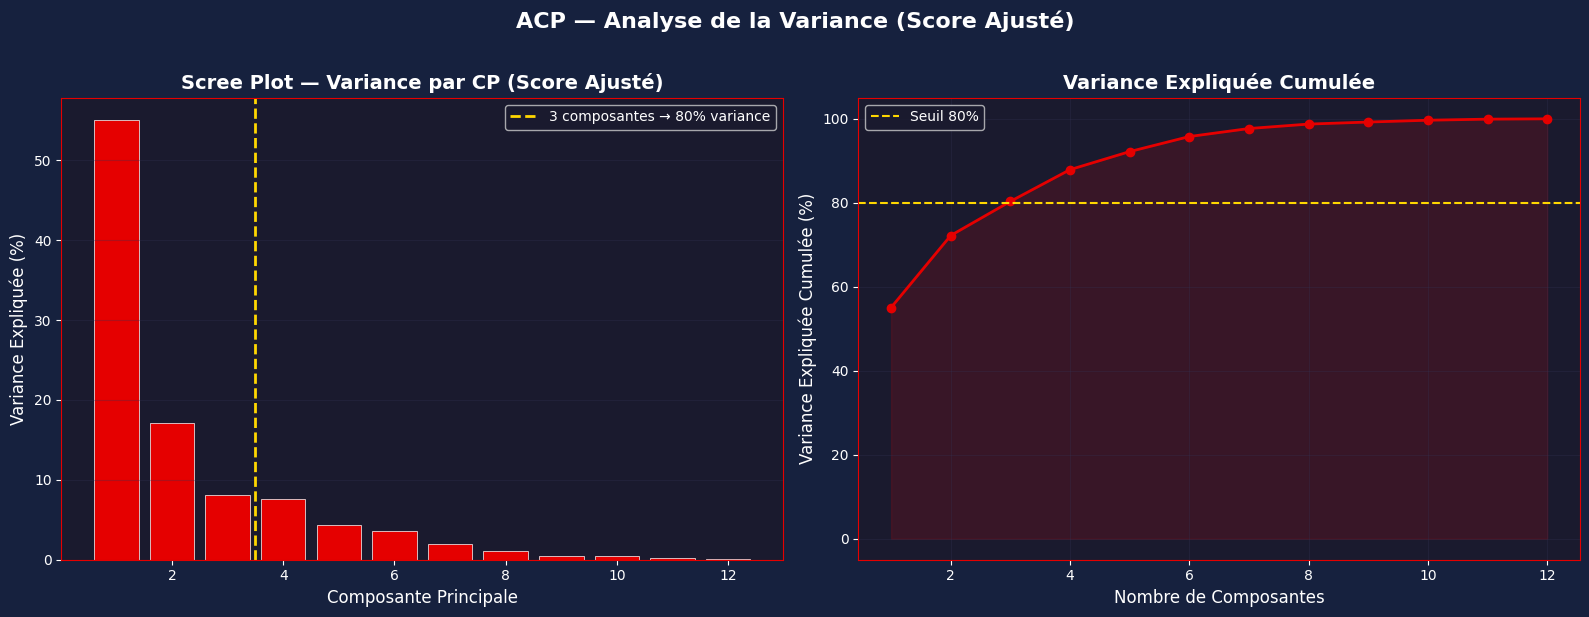

In [111]:
# ── Scree Plot ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax1 = axes[0]
ax1.bar(range(1, len(variance_ratio)+1), variance_ratio*100,
        color='#e50000', edgecolor='white', linewidth=0.5)
ax1.axvline(x=n_comp_80+0.5, color='#ffd700', linestyle='--', linewidth=2,
            label=f'{n_comp_80} composantes → 80% variance')
ax1.set_xlabel('Composante Principale', fontsize=12)
ax1.set_ylabel('Variance Expliquée (%)', fontsize=12)
ax1.set_title('Scree Plot — Variance par CP (Score Ajusté)', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(axis='y', alpha=0.3)

ax2 = axes[1]
ax2.plot(range(1, len(cumulative_variance)+1), cumulative_variance*100,
         'o-', color='#e50000', linewidth=2, markersize=6)
ax2.axhline(y=80, color='#ffd700', linestyle='--', linewidth=1.5, label='Seuil 80%')
ax2.fill_between(range(1, len(cumulative_variance)+1), cumulative_variance*100,
                 alpha=0.15, color='#e50000')
ax2.set_xlabel('Nombre de Composantes', fontsize=12)
ax2.set_ylabel('Variance Expliquée Cumulée (%)', fontsize=12)
ax2.set_title('Variance Expliquée Cumulée', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)

plt.suptitle('ACP — Analyse de la Variance (Score Ajusté)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

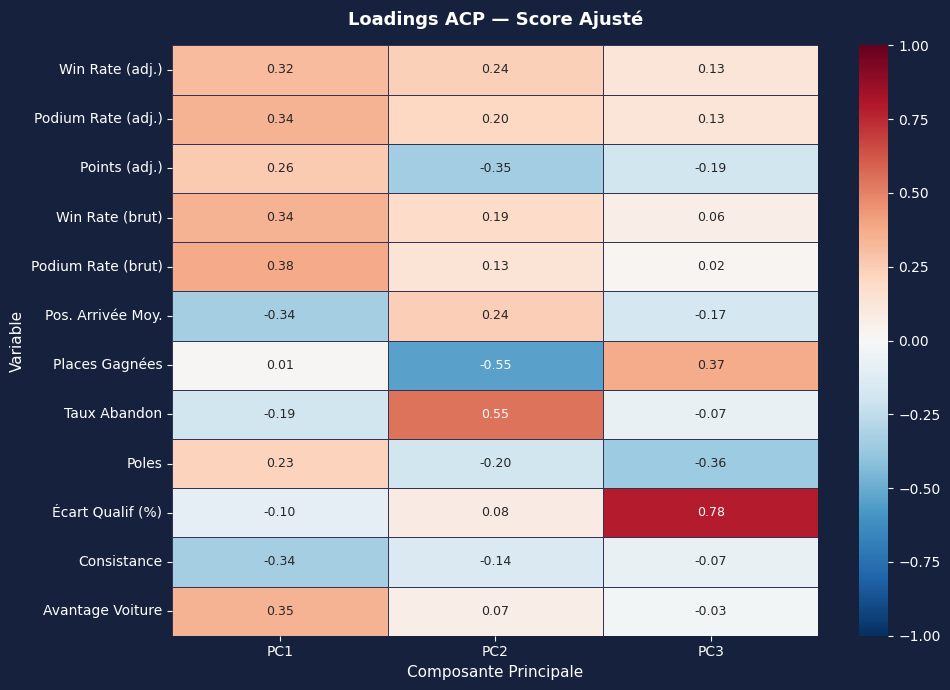

In [112]:
# ── Heatmap des loadings ──────────────────────────────────────────────────
pca_final = PCA(n_components=min(n_comp_80, len(PCA_FEATURES)), random_state=42)
X_pca = pca_final.fit_transform(X_scaled)

loadings = pd.DataFrame(
    pca_final.components_.T,
    index=PCA_FEATURES,
    columns=[f'PC{i+1}' for i in range(pca_final.n_components_)]
)

short_names = {
    'career_adjusted_win_rate'    : 'Win Rate (adj.)',
    'career_adjusted_podium_rate' : 'Podium Rate (adj.)',
    'career_adjusted_points'      : 'Points (adj.)',
    'career_win_rate'             : 'Win Rate (brut)',
    'career_podium_rate'          : 'Podium Rate (brut)',
    'career_avg_finish_pos'       : 'Pos. Arrivée Moy.',
    'career_positions_gained'     : 'Places Gagnées',
    'career_dnf_rate'             : 'Taux Abandon',
    'career_pole_positions'       : 'Poles',
    'career_avg_quali_gap_pct'    : 'Écart Qualif (%)',
    'career_consistency'          : 'Consistance',
    'career_car_advantage_ratio'  : 'Avantage Voiture',
}
loadings.index = [short_names.get(i, i) for i in loadings.index]

fig, ax = plt.subplots(figsize=(max(10, pca_final.n_components_*1.2), 7))
sns.heatmap(loadings.iloc[:, :min(6, pca_final.n_components_)],
            annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.5, linecolor='#333355', annot_kws={'size': 9}, ax=ax)
ax.set_title('Loadings ACP — Score Ajusté', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Composante Principale', fontsize=11)
ax.set_ylabel('Variable', fontsize=11)
plt.tight_layout()
plt.show()

In [113]:
# ── Variables à polarité négative & Score composite ajusté ───────────────
NEGATIVE_POLARITY = {
    'career_avg_finish_pos'    : True,
    'career_dnf_rate'          : True,
    'career_avg_quali_gap_pct' : True,
    'career_car_advantage_ratio': False
}

X_corrected = X_scaled.copy()
for i, feat in enumerate(PCA_FEATURES):
    if NEGATIVE_POLARITY.get(feat, False):
        X_corrected[:, i] *= -1

pca_corrected = PCA(n_components=n_comp_80, random_state=42)
X_pca_corrected = pca_corrected.fit_transform(X_corrected)
weights = pca_corrected.explained_variance_ratio_
score_raw = X_pca_corrected @ weights

# Normalisation 0-100
score_min, score_max = score_raw.min(), score_raw.max()
score_100 = (score_raw - score_min) / (score_max - score_min) * 100

career_df_filtered = career_df_filtered.copy()
career_df_filtered['score_ajuste']     = score_100
career_df_filtered['pca_score_raw']    = score_raw

for i in range(n_comp_80):
    career_df_filtered[f'PC{i+1}_score'] = X_pca_corrected[:, i]

ranking_adj = (
    career_df_filtered
    .sort_values('score_ajuste', ascending=False)
    .reset_index(drop=True)
)
ranking_adj.index = ranking_adj.index + 1

print("🏆 TOP 20 SCORE AJUSTÉ (neutralisation voiture & ère) :")
print("="*75)
cols_display = ['driver_name', 'nationality', 'total_wins', 'total_podiums',
                'total_races', 'total_seasons', 'score_ajuste']
print(ranking_adj[cols_display].head(20).to_string())

🏆 TOP 20 SCORE AJUSTÉ (neutralisation voiture & ère) :
           driver_name    nationality  total_wins  total_podiums  total_races  total_seasons  score_ajuste
1       Lewis Hamilton        British         105            202          356             18    100.000000
2       Max Verstappen          Dutch          63            112          209             10     95.695736
3          Juan Fangio      Argentine          24             35           56              7     88.593491
4     Sebastian Vettel         German          53            122          300             16     79.229064
5   Michael Schumacher         German          91            155          308             19     77.211766
6      Charles Leclerc     Monegasque           8             43          149              7     69.552898
7            Jim Clark        British          24             31           72              8     68.722480
8          Alain Prost         French          51            106          202            

## 8. Comparaison : Score Brut vs Score Ajusté

Cette section met en évidence **l'impact de la neutralisation** (avantage voiture + ère) sur le classement.  
Un pilote dont le rang monte après correction avait des performances **sous-estimées** par sa voiture / son époque.  
Un pilote dont le rang baisse bénéficiait d'un **avantage technologique** significatif.

In [114]:
# ── Fusion des deux classements ──────────────────────────────────────────
rank_brut = ranking_brut[['driver_name', 'score_brut']].copy()
rank_brut['rang_brut'] = range(1, len(rank_brut)+1)

rank_adj  = ranking_adj[['driver_name', 'score_ajuste']].copy()
rank_adj['rang_ajuste'] = range(1, len(rank_adj)+1)

comparison = rank_brut.merge(rank_adj, on='driver_name', how='inner')
comparison['delta_rang'] = comparison['rang_brut'] - comparison['rang_ajuste']
# delta > 0 → pilote monte dans le classement après correction (sous-estimé)
# delta < 0 → pilote descend après correction (sur-estimé par la voiture)

print("📊 Comparaison Score Brut vs Score Ajusté — TOP 20 (classement ajusté)")
print("="*85)
print(f"{'Pilote':<25} {'Rang Brut':>10} {'Rang Ajusté':>12} {'Δ Rang':>8} {'Score Brut':>11} {'Score Ajusté':>13}")
print("-"*85)
for _, row in comparison[comparison['rang_ajuste'] <= 20].iterrows():
    arrow = "▲" if row['delta_rang'] > 0 else ("▼" if row['delta_rang'] < 0 else "=")
    print(f"{row['driver_name']:<25} {row['rang_brut']:>10.0f} {row['rang_ajuste']:>12.0f} "
          f"{arrow}{abs(row['delta_rang']):>6.0f} {row['score_brut']:>11.2f} {row['score_ajuste']:>13.2f}")

print("\nℹ️  ▲ = monte dans le classement après correction (voiture moins bonne / ère difficile)")
print("   ▼ = descend après correction (bénéficiait d'un avantage voiture / ère favorable)")

📊 Comparaison Score Brut vs Score Ajusté — TOP 20 (classement ajusté)
Pilote                     Rang Brut  Rang Ajusté   Δ Rang  Score Brut  Score Ajusté
-------------------------------------------------------------------------------------
Lewis Hamilton                     1            1 =     0      100.00        100.00
Max Verstappen                     2            2 =     0       92.94         95.70
Sebastian Vettel                   3            4 ▼     1       81.60         79.23
Michael Schumacher                 4            5 ▼     1       80.74         77.21
Juan Fangio                        5            3 ▲     2       79.83         88.59
Charles Leclerc                    6            6 =     0       72.97         69.55
Nico Rosberg                       7           10 ▼     3       71.13         65.10
Alain Prost                        8            8 =     0       68.65         66.65
Jim Clark                          9            7 ▲     2       67.35         68.72
Ayr

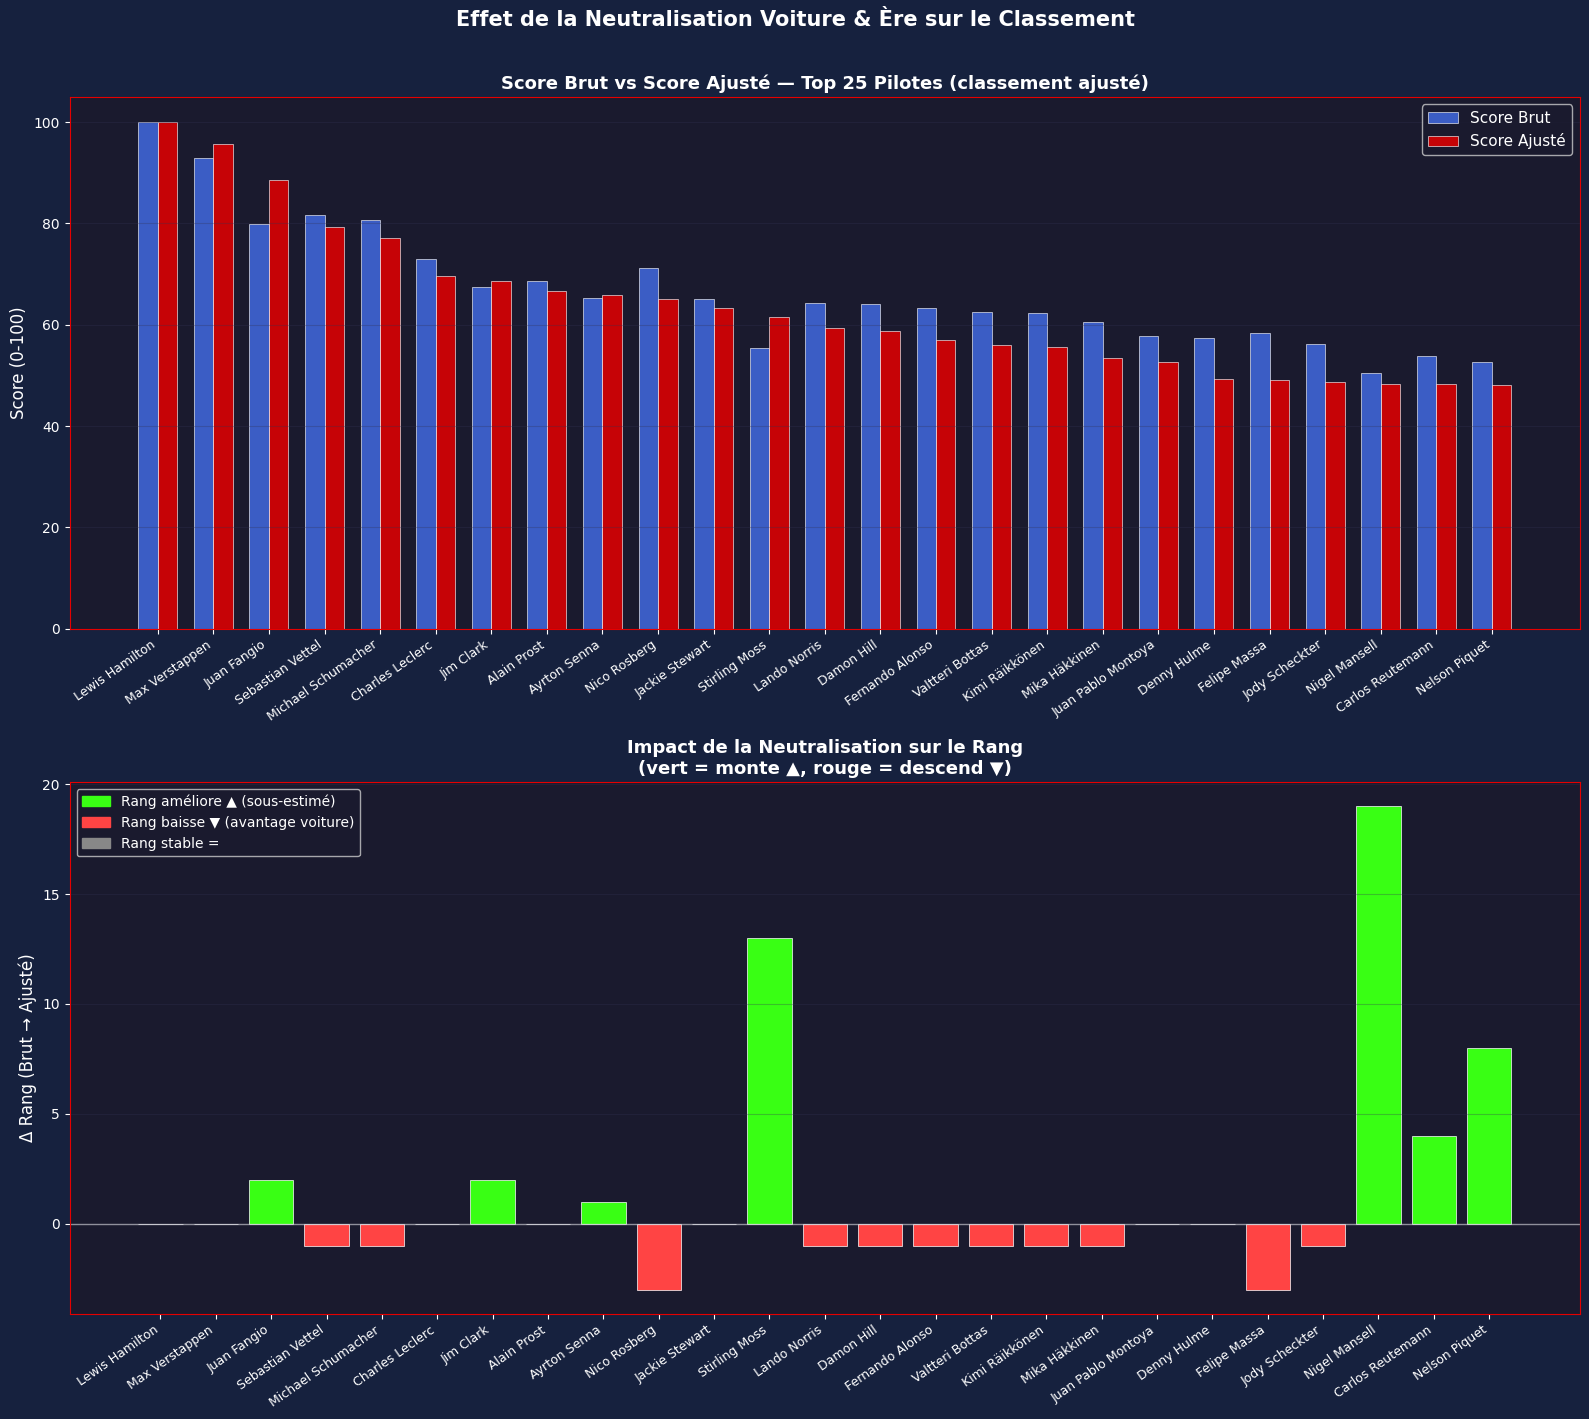

In [115]:
# ── Visualisation comparative ─────────────────────────────────────────────
top_n = 25
cmp = comparison[comparison['rang_ajuste'] <= top_n].sort_values('rang_ajuste')
names   = cmp['driver_name'].tolist()
x       = np.arange(len(names))
width   = 0.35

fig, axes = plt.subplots(2, 1, figsize=(16, 14))

# — Subplot 1 : Scores côte à côte —
ax1 = axes[0]
bars1 = ax1.bar(x - width/2, cmp['score_brut'],   width, label='Score Brut',    color='#4169e1', alpha=0.85, edgecolor='white', linewidth=0.5)
bars2 = ax1.bar(x + width/2, cmp['score_ajuste'], width, label='Score Ajusté',  color='#e50000', alpha=0.85, edgecolor='white', linewidth=0.5)
ax1.set_xticks(x)
ax1.set_xticklabels(names, rotation=35, ha='right', fontsize=9)
ax1.set_ylabel('Score (0-100)', fontsize=12)
ax1.set_title(f'Score Brut vs Score Ajusté — Top {top_n} Pilotes (classement ajusté)',
              fontsize=13, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(axis='y', alpha=0.3)

# — Subplot 2 : Δ Rang —
ax2 = axes[1]
deltas = cmp['delta_rang'].tolist()
bar_colors = ['#39ff14' if d > 0 else ('#ff4444' if d < 0 else '#888888') for d in deltas]
ax2.bar(x, deltas, color=bar_colors, edgecolor='white', linewidth=0.5)
ax2.axhline(0, color='white', linewidth=1, alpha=0.5)
ax2.set_xticks(x)
ax2.set_xticklabels(names, rotation=35, ha='right', fontsize=9)
ax2.set_ylabel('Δ Rang (Brut → Ajusté)', fontsize=12)
ax2.set_title('Impact de la Neutralisation sur le Rang\n'
              '(vert = monte ▲, rouge = descend ▼)', fontsize=13, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# Légende couleurs
patch_up   = mpatches.Patch(color='#39ff14', label='Rang améliore ▲ (sous-estimé)')
patch_down = mpatches.Patch(color='#ff4444', label='Rang baisse ▼ (avantage voiture)')
patch_eq   = mpatches.Patch(color='#888888', label='Rang stable =')
ax2.legend(handles=[patch_up, patch_down, patch_eq], fontsize=10)

plt.suptitle('Effet de la Neutralisation Voiture & Ère sur le Classement',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("comparaison_brut_vs_ajuste.png", dpi=150, bbox_inches='tight',
            facecolor='#16213e')
plt.show()

## 9. Visualisations du Classement Final (Score Ajusté)

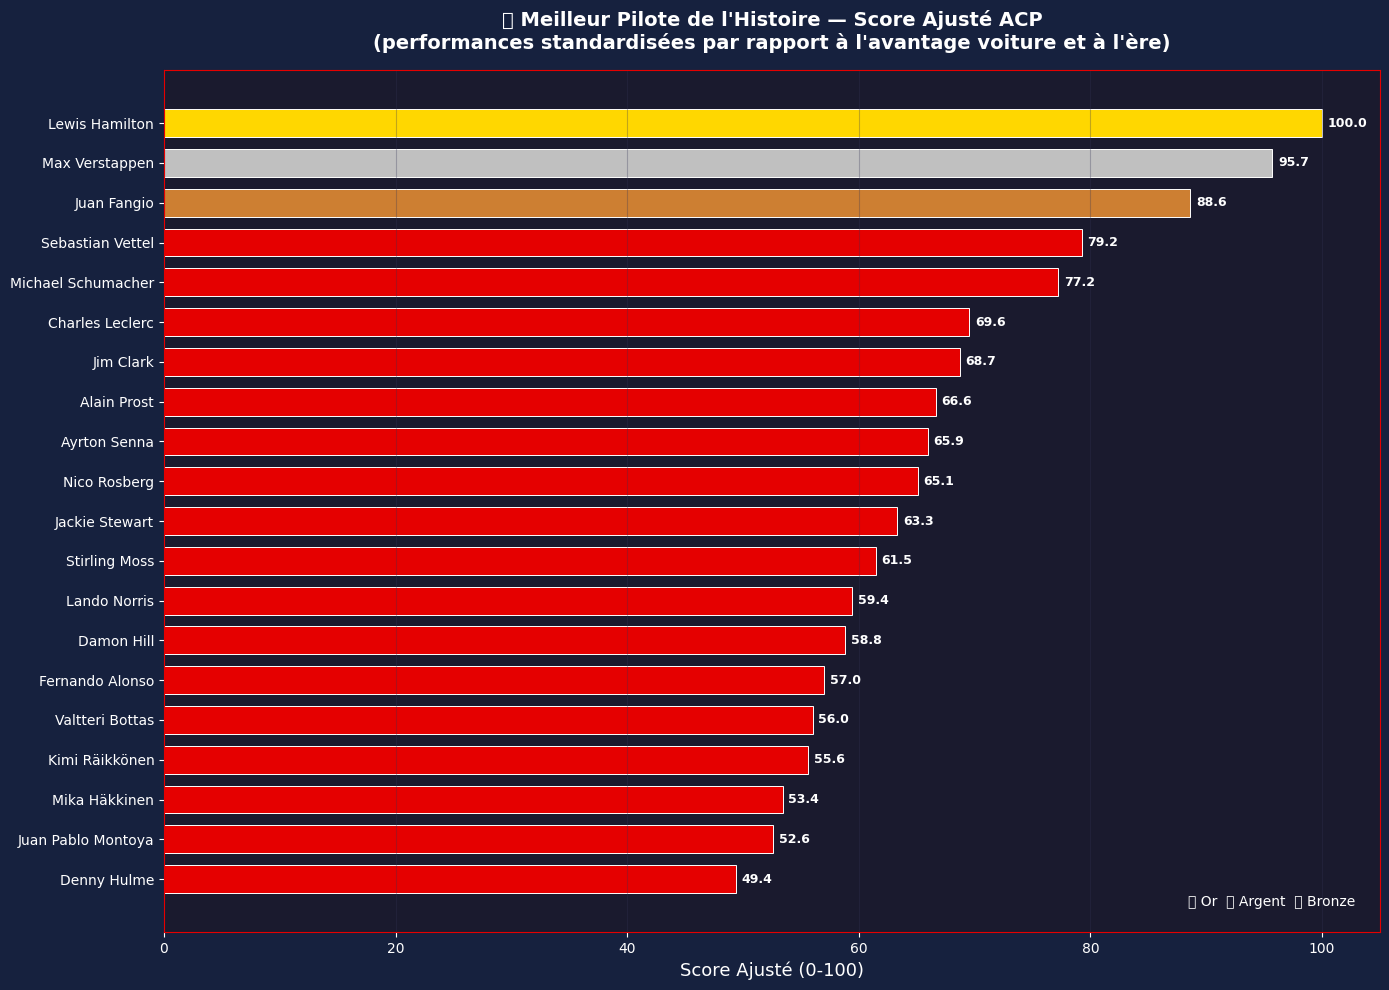

In [116]:
# ── 9a. Top 20 Score Ajusté — Barplot horizontal ────────────────────────
top20 = ranking_adj.head(20).iloc[::-1]

fig, ax = plt.subplots(figsize=(14, 10))
colors = [
    '#ffd700' if i == len(top20)-1 else
    '#c0c0c0' if i == len(top20)-2 else
    '#cd7f32' if i == len(top20)-3 else
    '#e50000'
    for i in range(len(top20))
]
bars = ax.barh(top20['driver_name'], top20['score_ajuste'],
               color=colors, edgecolor='white', linewidth=0.7, height=0.7)
for bar, score in zip(bars, top20['score_ajuste']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{score:.1f}', va='center', ha='left', fontsize=9,
            color='white', fontweight='bold')
ax.set_xlim(0, 105)
ax.set_xlabel('Score Ajusté (0-100)', fontsize=13)
ax.set_title("🏆 Meilleur Pilote de l'Histoire — Score Ajusté ACP\n"
             "(performances standardisées par rapport à l'avantage voiture et à l'ère)",
             fontsize=14, fontweight='bold', pad=15)
ax.grid(axis='x', alpha=0.3)
ax.text(0.98, 0.03, '🥇 Or  🥈 Argent  🥉 Bronze',
        transform=ax.transAxes, ha='right', fontsize=10, color='white')
plt.tight_layout()
plt.savefig("score_ajuste_top20.png", dpi=150, bbox_inches='tight',
            facecolor='#16213e')
plt.show()

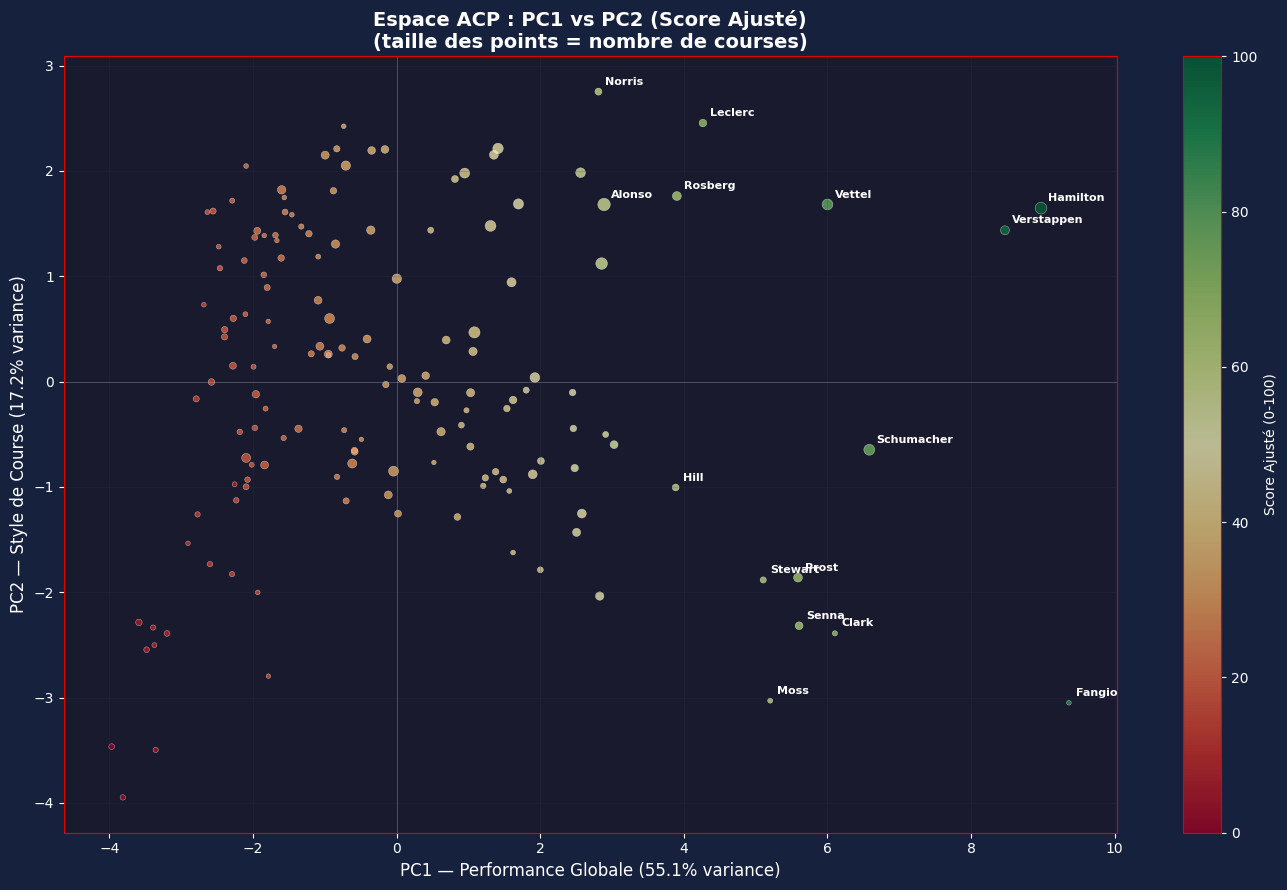

In [117]:
# ── 9b. Scatter PC1 vs PC2 avec labels top pilotes ──────────────────────
fig, ax = plt.subplots(figsize=(14, 9))
sc = ax.scatter(
    X_pca_corrected[:, 0], X_pca_corrected[:, 1],
    c=score_100, cmap='RdYlGn',
    s=career_df_filtered['total_races'] / 5,
    alpha=0.7, edgecolors='white', linewidth=0.3
)
plt.colorbar(sc, ax=ax, label='Score Ajusté (0-100)')

top15_names = set(ranking_adj.head(15)['driver_name'].tolist())
for pos_arr, (_, row) in enumerate(career_df_filtered.iterrows()):
    if row['driver_name'] in top15_names:
        ax.annotate(
            row['driver_name'].split()[-1],
            (X_pca_corrected[pos_arr, 0], X_pca_corrected[pos_arr, 1]),
            fontsize=8, color='white', fontweight='bold',
            xytext=(5, 5), textcoords='offset points'
        )

var1 = pca_corrected.explained_variance_ratio_[0] * 100
var2 = pca_corrected.explained_variance_ratio_[1] * 100
ax.set_xlabel(f'PC1 — Performance Globale ({var1:.1f}% variance)', fontsize=12)
ax.set_ylabel(f'PC2 — Style de Course ({var2:.1f}% variance)', fontsize=12)
ax.set_title('Espace ACP : PC1 vs PC2 (Score Ajusté)\n'
             '(taille des points = nombre de courses)', fontsize=14, fontweight='bold')
ax.axhline(0, color='white', linewidth=0.5, alpha=0.3)
ax.axvline(0, color='white', linewidth=0.5, alpha=0.3)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

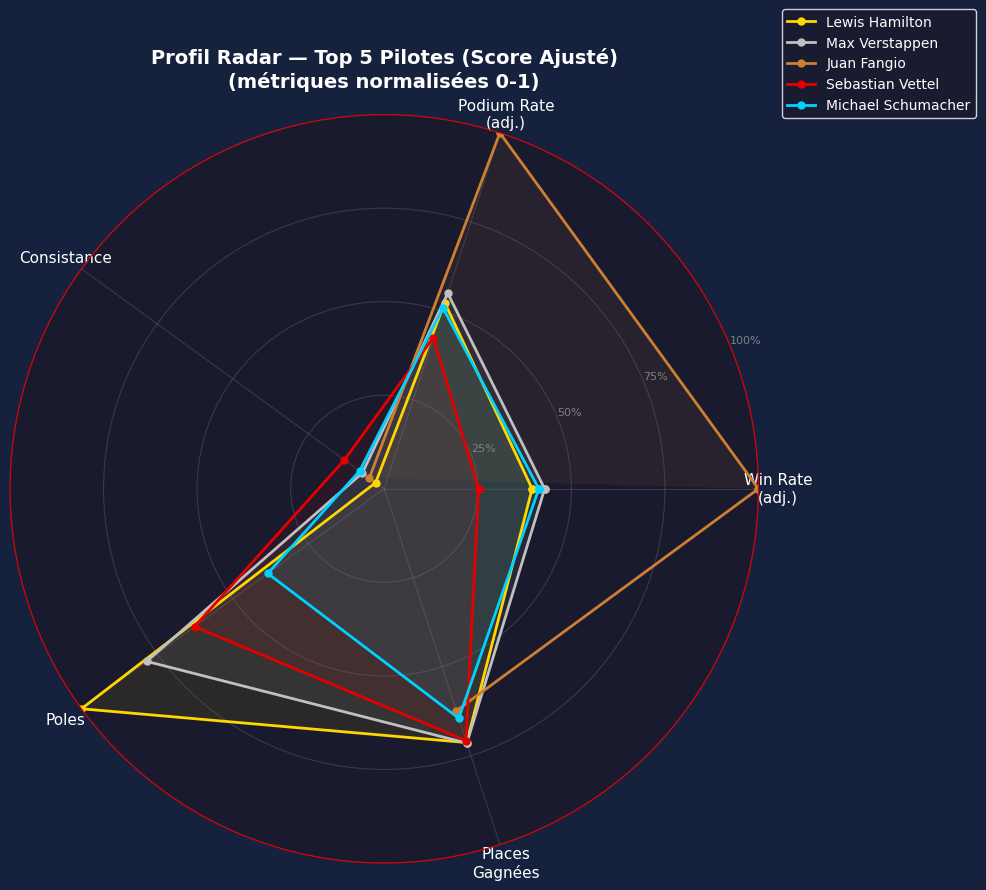

In [118]:
# ── 9c. Radar Chart — Profil des Top 5 ──────────────────────────────────
top5 = ranking_adj.head(5)
radar_features = [
    'career_adjusted_win_rate', 'career_adjusted_podium_rate',
    'career_consistency', 'career_pole_positions', 'career_positions_gained'
]
radar_labels = ['Win Rate\n(adj.)', 'Podium Rate\n(adj.)', 'Consistance',
                'Poles', 'Places\nGagnées']

radar_data = career_df_filtered[radar_features].copy().reset_index(drop=True)
for col in radar_features:
    col_min, col_max = radar_data[col].min(), radar_data[col].max()
    radar_data[col] = (radar_data[col] - col_min) / (col_max - col_min + 1e-9)

N = len(radar_features)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
ax.set_facecolor('#1a1a2e')
fig.patch.set_facecolor('#16213e')

radar_colors = ['#ffd700', '#c0c0c0', '#cd7f32', '#e50000', '#00d2ff']
name_to_pos = {row['driver_name']: pos
               for pos, (_, row) in enumerate(career_df_filtered.iterrows())}

for idx_rank, (_, row) in enumerate(top5.iterrows()):
    pos = name_to_pos.get(row['driver_name'], None)
    if pos is None: continue
    values = radar_data.iloc[pos].tolist() + [radar_data.iloc[pos].tolist()[0]]
    ax.plot(angles, values, 'o-', linewidth=2,
            color=radar_colors[idx_rank], label=row['driver_name'], markersize=5)
    ax.fill(angles, values, alpha=0.08, color=radar_colors[idx_rank])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, fontsize=11, color='white')
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['25%', '50%', '75%', '100%'], fontsize=8, color='gray')
ax.grid(color='gray', alpha=0.3)
ax.spines['polar'].set_color('#e50000')
ax.set_title('Profil Radar — Top 5 Pilotes (Score Ajusté)\n(métriques normalisées 0-1)',
             fontsize=14, fontweight='bold', color='white', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.15),
          fontsize=10, facecolor='#1a1a2e', edgecolor='white', labelcolor='white')
plt.tight_layout()
plt.show()

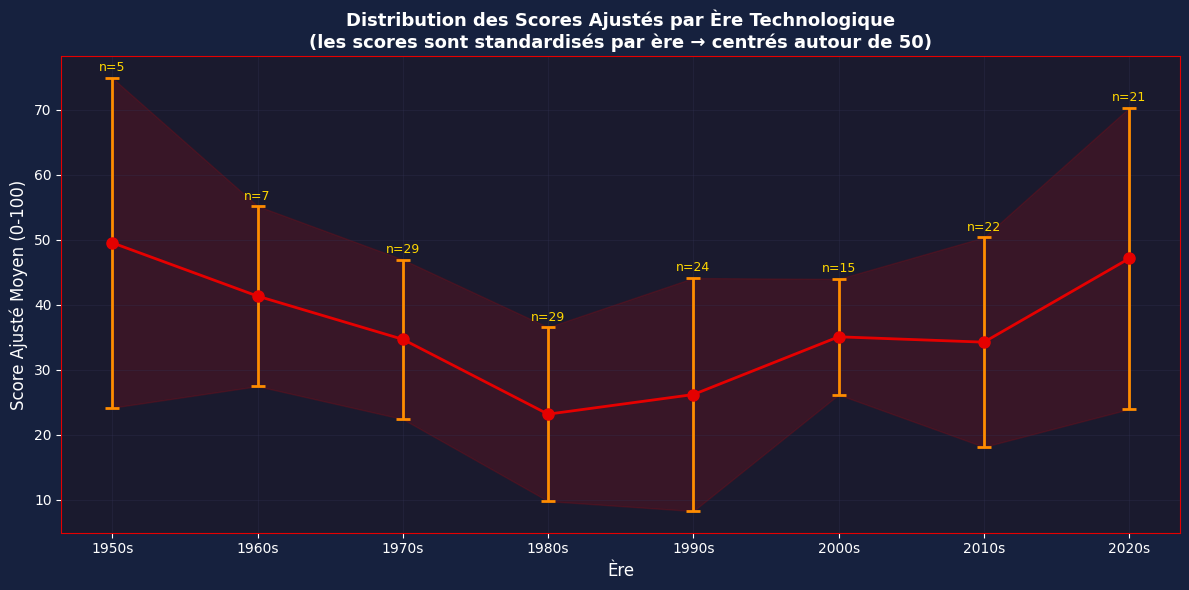

In [119]:
# ── 9d. Évolution du score moyen par ère ──────────────────────────────────
era_order = ['1950s','1960s','1970s','1980s','1990s','2000s','2010s','2020s']
era_stats = (
    career_df_filtered.groupby('era')['score_ajuste']
    .agg(['mean','std','count'])
    .reindex([e for e in era_order if e in career_df_filtered['era'].unique()])
)

fig, ax = plt.subplots(figsize=(12, 6))
ax.errorbar(era_stats.index, era_stats['mean'], yerr=era_stats['std'],
            fmt='o-', color='#e50000', linewidth=2, markersize=8,
            capsize=5, capthick=2, ecolor='#ff8c00')
ax.fill_between(era_stats.index,
                era_stats['mean'] - era_stats['std'],
                era_stats['mean'] + era_stats['std'],
                alpha=0.15, color='#e50000')
ax.set_xlabel('Ère', fontsize=12)
ax.set_ylabel('Score Ajusté Moyen (0-100)', fontsize=12)
ax.set_title('Distribution des Scores Ajustés par Ère Technologique\n'
             '(les scores sont standardisés par ère → centrés autour de 50)',
             fontsize=13, fontweight='bold')
ax.grid(alpha=0.3)
for era, row in era_stats.iterrows():
    ax.annotate(f"n={int(row['count'])}",
                (era, row['mean'] + row['std'] + 1),
                ha='center', fontsize=9, color='#ffd700')
plt.tight_layout()
plt.show()

## 10. Analyse Approfondie — Décomposition du Score

In [120]:
# ── Tableau détaillé top 10 ──────────────────────────────────────────────
top10 = ranking_adj.head(10).copy()

display_cols = {
    'driver_name'              : 'Pilote',
    'nationality'              : 'Nationalité',
    'total_wins'               : 'Victoires',
    'total_podiums'            : 'Podiums',
    'total_races'              : 'Courses',
    'total_seasons'            : 'Saisons',
    'career_adjusted_win_rate' : 'Win Rate (adj.)',
    'career_consistency'       : 'Consistance',
    'career_dnf_rate'          : 'Taux Abandon',
    'score_brut'               : 'Score Brut',
    'score_ajuste'             : 'Score Ajusté',
}
# Associer score_brut au top10 via nom
top10 = top10.merge(
    comparison[['driver_name', 'score_brut', 'rang_brut', 'delta_rang']],
    on='driver_name', how='left'
)
top10_display = top10[[c for c in display_cols if c in top10.columns]].rename(columns=display_cols)
top10_display.index = range(1, len(top10_display)+1)

for col in ['Win Rate (adj.)', 'Consistance', 'Taux Abandon']:
    if col in top10_display.columns:
        top10_display[col] = top10_display[col].map('{:.3f}'.format)
for col in ['Score Brut', 'Score Ajusté']:
    if col in top10_display.columns:
        top10_display[col] = top10_display[col].map('{:.2f}'.format)

print("\n🏆 TOP 10 DÉTAILLÉ (Score Ajusté) :")
print("="*100)
print(top10_display.to_string())


🏆 TOP 10 DÉTAILLÉ (Score Ajusté) :
                Pilote Nationalité  Victoires  Podiums  Courses  Saisons Win Rate (adj.) Consistance Taux Abandon Score Brut Score Ajusté
1       Lewis Hamilton     British        105      202      356       18           0.284       0.501        0.084     100.00       100.00
2       Max Verstappen       Dutch         63      112      209       10           0.308       0.516        0.144      92.94        95.70
3          Juan Fangio   Argentine         24       35       56        7           0.717       0.508        0.250      79.83        88.59
4     Sebastian Vettel      German         53      122      300       16           0.181       0.538        0.127      81.60        79.23
5   Michael Schumacher      German         91      155      308       19           0.296       0.520        0.218      80.74        77.21
6      Charles Leclerc  Monegasque          8       43      149        7           0.061       0.568        0.154      72.97        69.5

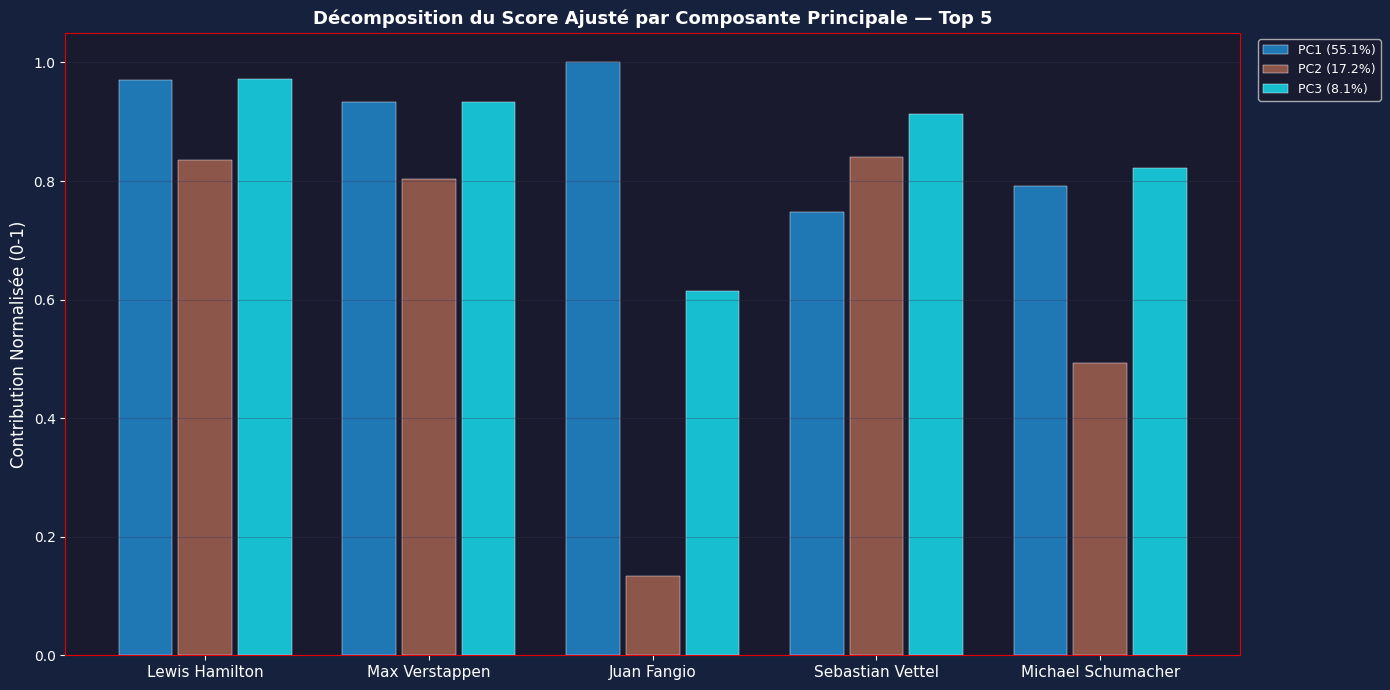

In [121]:
# ── Contribution de chaque PC au score des top 5 ─────────────────────────
fig, ax = plt.subplots(figsize=(14, 7))

top5_names   = ranking_adj.head(5)['driver_name'].tolist()
name_to_pos2 = {row['driver_name']: pos
                for pos, (_, row) in enumerate(career_df_filtered.iterrows())}
top5_indices = [name_to_pos2[n] for n in top5_names if n in name_to_pos2]

pc_cols  = [f'PC{i+1}_score' for i in range(n_comp_80)]
pc_data  = career_df_filtered[pc_cols].copy().reset_index(drop=True)
for col in pc_cols:
    col_min, col_max = pc_data[col].min(), pc_data[col].max()
    pc_data[col] = (pc_data[col] - col_min) / (col_max - col_min + 1e-9)

x         = np.arange(len(top5_names))
width     = 0.8 / n_comp_80
colors_pc = plt.cm.tab10(np.linspace(0, 1, n_comp_80))

for i, pc_col in enumerate(pc_cols):
    vals      = [pc_data.iloc[j][pc_col] for j in top5_indices]
    label_var = pca_corrected.explained_variance_ratio_[i] * 100
    ax.bar(x + i * width - 0.4 + width / 2, vals, width=width * 0.9,
           color=colors_pc[i], label=f'PC{i+1} ({label_var:.1f}%)',
           edgecolor='white', linewidth=0.3)

ax.set_xticks(x)
ax.set_xticklabels(top5_names, fontsize=11)
ax.set_ylabel('Contribution Normalisée (0-1)', fontsize=12)
ax.set_title('Décomposition du Score Ajusté par Composante Principale — Top 5',
             fontsize=13, fontweight='bold')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Résumé & Conclusions

In [122]:
print("=" * 70)
print("  RÉSUMÉ — MEILLEUR PILOTE DE L'HISTOIRE F1")
print("=" * 70)

print(f"\n📊 Méthode :")
print(f"   • {len(PCA_FEATURES_BRUT)} variables pour le score brut")
print(f"   • {len(PCA_FEATURES)} variables pour le score ajusté")
print(f"   • Neutralisation avantage voiture (ratio constructeur/meilleur)")
print(f"   • {n_comp_80} composantes principales (≥80% variance expliquée)")
print(f"   • Score composite pondéré par variance expliquée")

print(f"\n🏎️  Pilotes analysés : {len(career_df_filtered)} (avec ≥50 courses)")

print(f"\n📊 TOP 10 SCORE BRUT (avant correction) :")
for rank_pos, (_, row) in enumerate(ranking_brut.head(10).iterrows(), 1):
    medal = {1: '🥇', 2: '🥈', 3: '🥉'}.get(rank_pos, f'  {rank_pos}.')
    print(f"   {medal} {row['driver_name']:<25} | Score Brut: {row['score_brut']:5.2f}")

print(f"\n🏆 TOP 10 SCORE AJUSTÉ (après correction voiture & ère) :")
for rank_pos, (_, row) in enumerate(ranking_adj.head(10).iterrows(), 1):
    medal = {1: '🥇', 2: '🥈', 3: '🥉'}.get(rank_pos, f'  {rank_pos}.')
    # Trouver rang brut
    brut_info = comparison[comparison['driver_name'] == row['driver_name']]
    rang_brut_str = f"(était #{int(brut_info['rang_brut'].values[0])} en brut)" if len(brut_info) > 0 else ""
    print(f"   {medal} {row['driver_name']:<25} | Score Ajusté: {row['score_ajuste']:5.2f} {rang_brut_str}")

winner = ranking_adj.iloc[0]
print(f"\n✅ Conclusion : D'après l'indice composite ACP ajusté, le meilleur pilote de")
print(f"   l'histoire de la F1 est {winner['driver_name'].upper()}.")
print(f"   (Score Ajusté: {winner['score_ajuste']:.2f}/100)")
print("=" * 70)

  RÉSUMÉ — MEILLEUR PILOTE DE L'HISTOIRE F1

📊 Méthode :
   • 8 variables pour le score brut
   • 12 variables pour le score ajusté
   • Neutralisation avantage voiture (ratio constructeur/meilleur)
   • 3 composantes principales (≥80% variance expliquée)
   • Score composite pondéré par variance expliquée

🏎️  Pilotes analysés : 152 (avec ≥50 courses)

📊 TOP 10 SCORE BRUT (avant correction) :
   🥇 Lewis Hamilton            | Score Brut: 100.00
   🥈 Max Verstappen            | Score Brut: 92.94
   🥉 Sebastian Vettel          | Score Brut: 81.60
     4. Michael Schumacher        | Score Brut: 80.74
     5. Juan Fangio               | Score Brut: 79.83
     6. Charles Leclerc           | Score Brut: 72.97
     7. Nico Rosberg              | Score Brut: 71.13
     8. Alain Prost               | Score Brut: 68.65
     9. Jim Clark                 | Score Brut: 67.35
     10. Ayrton Senna              | Score Brut: 65.30

🏆 TOP 10 SCORE AJUSTÉ (après correction voiture & ère) :
   🥇 Lewis H

In [123]:
# ── Fermeture Spark ───────────────────────────────────────────────────────
spark.stop()
print("✅ Session Spark fermée.")

✅ Session Spark fermée.


## 12. K-Means Clustering — Archétypes de Pilotes

L'ACP nous a projeté chaque pilote dans un espace de composantes principales.  
Le **clustering K-Means** va découper automatiquement cet espace en groupes homogènes,  
révélant des **archétypes** : des profils de pilotes qui se ressemblent par leur style et leurs performances.

**Pipeline :**
1. Méthode du coude (*Elbow*) + Score de Silhouette → choisir le k optimal
2. K-Means sur les coordonnées PCA corrigées
3. Caractérisation de chaque cluster (centroïdes dans l'espace des features)
4. Visualisation sur le plan PC1 × PC2
5. Tableau des pilotes par archétype

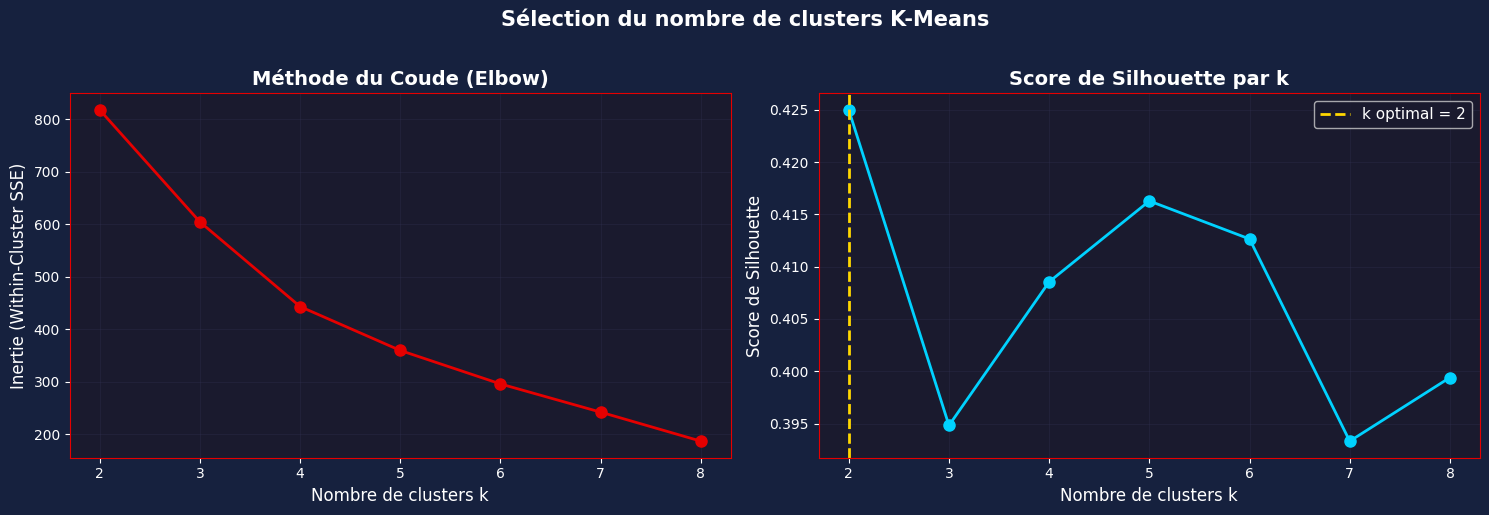

✅ k optimal (Silhouette) : 2
   Score de Silhouette max : 0.4250


In [124]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

# ── 12a. Choix du k optimal : Elbow + Silhouette ──────────────────────────
# On travaille sur les coordonnées ACP corrigées (X_pca_corrected)
# déjà calculées en section 7.

K_RANGE = range(2, 9)
inertias    = []
sil_scores  = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca_corrected)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_pca_corrected, labels))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Elbow
ax1 = axes[0]
ax1.plot(list(K_RANGE), inertias, 'o-', color='#e50000', linewidth=2, markersize=8)
ax1.set_xlabel('Nombre de clusters k', fontsize=12)
ax1.set_ylabel('Inertie (Within-Cluster SSE)', fontsize=12)
ax1.set_title('Méthode du Coude (Elbow)', fontsize=14, fontweight='bold')
ax1.grid(alpha=0.3)
ax1.set_xticks(list(K_RANGE))

# Silhouette
ax2 = axes[1]
ax2.plot(list(K_RANGE), sil_scores, 'o-', color='#00d2ff', linewidth=2, markersize=8)
ax2.set_xlabel('Nombre de clusters k', fontsize=12)
ax2.set_ylabel('Score de Silhouette', fontsize=12)
ax2.set_title('Score de Silhouette par k', fontsize=14, fontweight='bold')
ax2.grid(alpha=0.3)
ax2.set_xticks(list(K_RANGE))

# Annotation du meilleur k silhouette
best_k_sil = list(K_RANGE)[sil_scores.index(max(sil_scores))]
ax2.axvline(x=best_k_sil, color='#ffd700', linestyle='--', linewidth=2,
            label=f'k optimal = {best_k_sil}')
ax2.legend(fontsize=11)

plt.suptitle('Sélection du nombre de clusters K-Means', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"✅ k optimal (Silhouette) : {best_k_sil}")
print(f"   Score de Silhouette max : {max(sil_scores):.4f}")

In [125]:
# ── 12b. K-Means final ───────────────────────────────────────────────────
# Vous pouvez ajuster K_FINAL manuellement si le coude visuel
# suggère un k différent du maximum de Silhouette.
K_FINAL = 4  # ← modifier ici si besoin

kmeans = KMeans(n_clusters=K_FINAL, random_state=42, n_init=20)
cluster_labels = kmeans.fit_predict(X_pca_corrected)

career_df_filtered = ranking_adj.copy()
career_df_filtered['cluster'] = cluster_labels

# ── Caractérisation des clusters sur les features clés ──────────────────
feature_profile_cols = [
    'career_adjusted_win_rate',
    'career_adjusted_podium_rate',
    'career_consistency',
    'career_dnf_rate',
    'career_pole_positions',
    'career_positions_gained',
    'score_ajuste',
    'total_races',
    'total_wins',
]
feat_cols_available = [c for c in feature_profile_cols if c in career_df_filtered.columns]

cluster_profiles = (
    career_df_filtered
    .groupby('cluster')[feat_cols_available]
    .mean()
    .round(3)
)

print(f"✅ K-Means appliqué avec k = {K_FINAL}")
print(f"\n📊 Profil moyen par cluster :")
print(cluster_profiles.to_string())

# Répartition des pilotes par cluster
print(f"\n👥 Nombre de pilotes par cluster :")
print(career_df_filtered['cluster'].value_counts().sort_index().to_string())

✅ K-Means appliqué avec k = 4

📊 Profil moyen par cluster :
         career_adjusted_win_rate  career_adjusted_podium_rate  career_consistency  career_dnf_rate  career_pole_positions  career_positions_gained  score_ajuste  total_races  total_wins
cluster                                                                                                                                                                                   
0                           0.063                        0.204               0.670            0.395                  0.615                   -1.399        34.559      127.741       7.056
1                           0.060                        0.174               0.694            0.315                  1.053                   -0.452        37.251      133.300      14.000
2                           0.054                        0.196               0.666            0.445                  0.443                   -2.397        32.434      136.101       7.072
3    

In [126]:
# ── 12c. Nommage automatique des archétypes ──────────────────────────────
# On classe chaque cluster selon son score ajusté moyen
# et son taux de victoire ajusté.

archetype_labels = {}
ranked_clusters  = cluster_profiles['score_ajuste'].sort_values(ascending=False)

ARCHETYPE_NAMES = [
    "👑 Champions Dominants",
    "🏆 Grands Pilotes",
    "💪 Pilotes Solides",
    "🔧 Pilotes de Fond de Grille",
    "⚡ Spécialistes",
    "🛞 Pilotes de Passage",
    "🌱 Espoirs / Rookies",
    "📉 Pilotes Limités",
]

for rank, (cluster_id, _) in enumerate(ranked_clusters.items()):
    name = ARCHETYPE_NAMES[rank] if rank < len(ARCHETYPE_NAMES) else f"Groupe {rank+1}"
    archetype_labels[int(cluster_id)] = name

career_df_filtered['archetype'] = career_df_filtered['cluster'].map(archetype_labels)

print("🏷️  Archétypes attribués :")
for cid, name in sorted(archetype_labels.items()):
    n = (career_df_filtered['cluster'] == cid).sum()
    score_moy = career_df_filtered[career_df_filtered['cluster'] == cid]['score_ajuste'].mean()
    print(f"   Cluster {cid} → {name:<30} | {n:>3} pilotes | Score moyen : {score_moy:.2f}")

🏷️  Archétypes attribués :
   Cluster 0 → 🏆 Grands Pilotes               |  54 pilotes | Score moyen : 34.56
   Cluster 1 → 👑 Champions Dominants          |  10 pilotes | Score moyen : 37.25
   Cluster 2 → 🔧 Pilotes de Fond de Grille    |  69 pilotes | Score moyen : 32.43
   Cluster 3 → 💪 Pilotes Solides              |  19 pilotes | Score moyen : 33.34


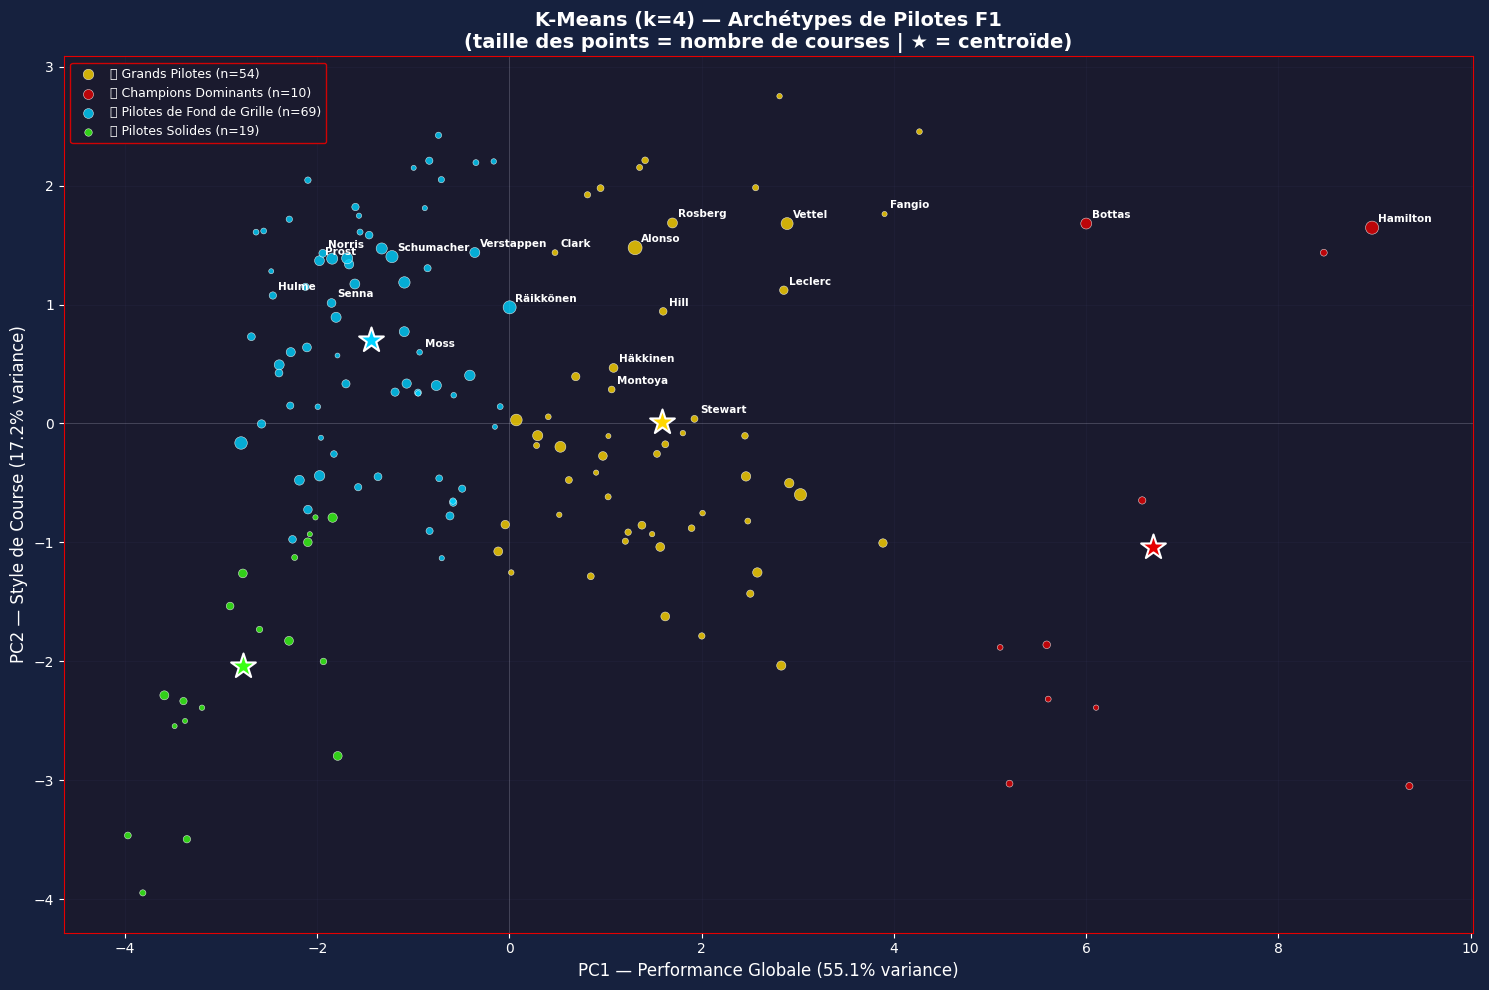

In [127]:
# ── 12d. Visualisation clusters sur PC1 × PC2 ────────────────────────────
CLUSTER_COLORS = ['#ffd700','#e50000','#00d2ff','#39ff14',
                  '#ff8c00','#c0c0c0','#ff69b4','#4169e1']

fig, ax = plt.subplots(figsize=(15, 10))

for cid in sorted(career_df_filtered['cluster'].unique()):
    mask    = career_df_filtered['cluster'] == cid
    indices = career_df_filtered[mask].index.tolist()
    # Récupérer les positions PCA (aligner sur career_df_filtered)
    df_sub  = career_df_filtered[mask].copy()
    df_sub  = df_sub.reset_index(drop=True)
    pca_idx = career_df_filtered[mask].index
    
    x_coords = X_pca_corrected[career_df_filtered.index.get_indexer(pca_idx), 0]
    y_coords = X_pca_corrected[career_df_filtered.index.get_indexer(pca_idx), 1]
    
    ax.scatter(
        x_coords, y_coords,
        c=CLUSTER_COLORS[cid % len(CLUSTER_COLORS)],
        s=career_df_filtered[mask]['total_races'].values / 4,
        alpha=0.80, edgecolors='white', linewidth=0.4,
        label=f"{archetype_labels[cid]} (n={mask.sum()})",
        zorder=3
    )

# Centroïdes
for cid, centroid in enumerate(kmeans.cluster_centers_):
    ax.scatter(centroid[0], centroid[1],
               marker='*', s=350,
               c=CLUSTER_COLORS[cid % len(CLUSTER_COLORS)],
               edgecolors='white', linewidth=1.5, zorder=5)

# Labels top pilotes
top20_names_set = set(ranking_adj.head(20)['driver_name'].tolist())
for pos_arr, (_, row) in enumerate(career_df_filtered.iterrows()):
    if row['driver_name'] in top20_names_set:
        ax.annotate(
            row['driver_name'].split()[-1],
            (X_pca_corrected[pos_arr, 0], X_pca_corrected[pos_arr, 1]),
            fontsize=7.5, color='white', fontweight='bold',
            xytext=(4, 4), textcoords='offset points',
            zorder=6
        )

var1 = pca_corrected.explained_variance_ratio_[0] * 100
var2 = pca_corrected.explained_variance_ratio_[1] * 100
ax.set_xlabel(f'PC1 — Performance Globale ({var1:.1f}% variance)', fontsize=12)
ax.set_ylabel(f'PC2 — Style de Course ({var2:.1f}% variance)', fontsize=12)
ax.set_title(f'K-Means (k={K_FINAL}) — Archétypes de Pilotes F1\n'
             '(taille des points = nombre de courses | ★ = centroïde)',
             fontsize=14, fontweight='bold')
ax.axhline(0, color='white', linewidth=0.4, alpha=0.3)
ax.axvline(0, color='white', linewidth=0.4, alpha=0.3)
ax.grid(alpha=0.2)
ax.legend(loc='upper left', fontsize=9,
          facecolor='#1a1a2e', edgecolor='#e50000', labelcolor='white',
          framealpha=0.9)

plt.tight_layout()
plt.savefig("kmeans_archetypes.png", dpi=150, bbox_inches='tight',
            facecolor='#16213e')
plt.show()

In [128]:
# ── 12e. Tableau des pilotes par archétype ───────────────────────────────
print("\n🏷️  PILOTES PAR ARCHÉTYPE\n" + "="*75)

for cid in sorted(archetype_labels.keys()):
    subset = (
        career_df_filtered[career_df_filtered['cluster'] == cid]
        .sort_values('score_ajuste', ascending=False)
    )
    print(f"\n{archetype_labels[cid]} — {len(subset)} pilotes")
    print("-"*65)
    cols_show = ['driver_name', 'total_wins', 'total_races',
                 'career_adjusted_win_rate', 'score_ajuste']
    cols_show = [c for c in cols_show if c in subset.columns]
    
    disp = subset[cols_show].head(10).copy()
    disp.columns = [c.replace('career_adjusted_win_rate', 'Win Rate Adj.')
                     .replace('score_ajuste', 'Score')
                     .replace('total_wins', 'Victoires')
                     .replace('total_races', 'Courses')
                     .replace('driver_name', 'Pilote')
                    for c in disp.columns]
    if 'Win Rate Adj.' in disp.columns:
        disp['Win Rate Adj.'] = disp['Win Rate Adj.'].map('{:.3f}'.format)
    if 'Score' in disp.columns:
        disp['Score'] = disp['Score'].map('{:.2f}'.format)
    print(disp.to_string(index=False))
    if len(subset) > 10:
        print(f"   ... et {len(subset)-10} autres pilotes")


🏷️  PILOTES PAR ARCHÉTYPE

🏆 Grands Pilotes — 54 pilotes
-----------------------------------------------------------------
            Pilote  Victoires  Courses Win Rate Adj. Score
       Juan Fangio         24       56         0.717 88.59
  Sebastian Vettel         53      300         0.181 79.23
   Charles Leclerc          8      149         0.061 69.55
         Jim Clark         24       72         0.481 68.72
      Nico Rosberg         23      206         0.114 65.10
    Jackie Stewart         27      100         0.279 63.32
        Damon Hill         22      122         0.189 58.78
   Fernando Alonso         32      404         0.085 57.02
     Mika Häkkinen         20      162         0.126 53.42
Juan Pablo Montoya          7       95         0.094 52.59
   ... et 44 autres pilotes

👑 Champions Dominants — 10 pilotes
-----------------------------------------------------------------
           Pilote  Victoires  Courses Win Rate Adj.  Score
   Lewis Hamilton        105      356 

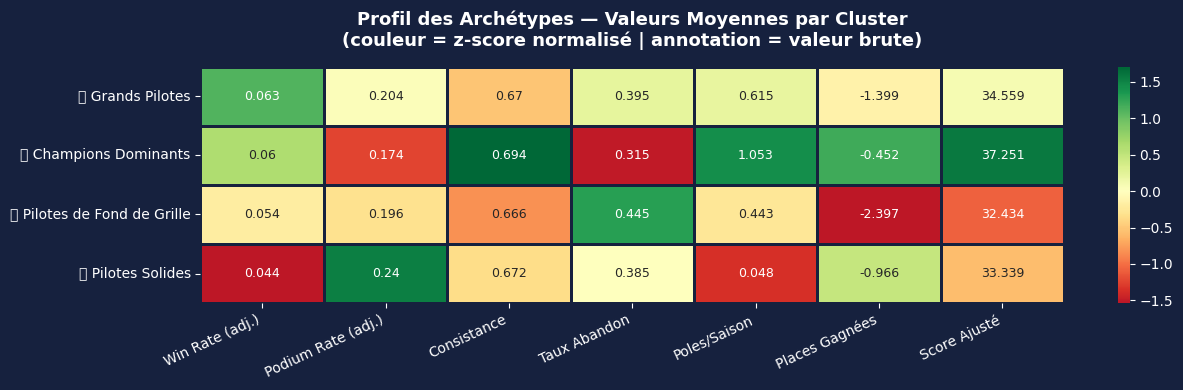

In [129]:
# ── 12f. Heatmap profils des clusters ─────────────────────────────────────
profile_display_cols = {
    'career_adjusted_win_rate'    : 'Win Rate (adj.)',
    'career_adjusted_podium_rate' : 'Podium Rate (adj.)',
    'career_consistency'          : 'Consistance',
    'career_dnf_rate'             : 'Taux Abandon',
    'career_pole_positions'       : 'Poles/Saison',
    'career_positions_gained'     : 'Places Gagnées',
    'score_ajuste'                : 'Score Ajusté',
}
pdf_cols = {k: v for k, v in profile_display_cols.items() if k in career_df_filtered.columns}

heatmap_df = (
    career_df_filtered
    .groupby('cluster')[list(pdf_cols.keys())]
    .mean()
    .rename(columns=pdf_cols)
)
heatmap_df.index = [archetype_labels[i] for i in heatmap_df.index]

# Normalisation colonne par colonne (z-score) pour comparer les profils
from scipy.stats import zscore
heatmap_normalized = heatmap_df.apply(zscore)

fig, ax = plt.subplots(figsize=(13, max(4, K_FINAL * 0.9)))
sns.heatmap(
    heatmap_normalized,
    annot=heatmap_df.round(3), fmt='',
    cmap='RdYlGn', center=0,
    linewidths=0.8, linecolor='#16213e',
    annot_kws={'size': 9},
    ax=ax
)
ax.set_title("Profil des Archétypes — Valeurs Moyennes par Cluster\n"
             "(couleur = z-score normalisé | annotation = valeur brute)",
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('')
ax.set_ylabel('')
plt.xticks(rotation=25, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.savefig("kmeans_heatmap_profils.png", dpi=150, bbox_inches='tight',
            facecolor='#16213e')
plt.show()

---

## Limites & Pistes d'Amélioration


### Limites méthodologiques
- **Données de temps au tour** : l'écart au meilleur tour de course est une métrique plus fine que la position finale, mais non disponible pour toute l'histoire de la F1.
- **Nombre de concurrents** : les années 50 avaient parfois moins de 10 voitures en course → la valeur d'une victoire n'est pas identique à une victoire moderne.
- **Changements de réglementation** : certaines saisons, les points n'étaient attribués qu'aux 6 premiers.
- **Facteur chance / fiabilité mécanique** : difficile à isoler complètement du talent pur.


*Dataset source : Ergast Motor Racing Database — http://ergast.com/mrd/*  
*Note : Ergast a cessé ses mises à jour fin 2024. Alternatives actives : FastF1, OpenF1 API.*